# KRITIS–Philippines: tropical cyclone × grid-bus screening (FINAL)

Canonical analysis notebook: **IBTrACS** (West Pacific) storms intersecting a **Philippines bounding box**, **gridded population** (WorldPop-style), and **PyPSA-Philippines grid buses**. The primary output is a ranked list of storms by a **footprint-style screening score** (`impact_score`), not a damage or outage model.

## How to read this notebook

**Thesis.** This work defines a **screening score** (`impact_score`): IBTrACS track wind, mapped with distance decay to **PyPSA-Philippines** buses, weighted by voltage and local **WorldPop** population (with an optional network adjustment from lines/generators). It is **not** a damage, outage, or loss model.

**Story (matches Run All order).**
1. **Data** — IBTrACS (West Pacific) → Philippines box → **Module 1** land mask → WorldPop → buses → **Module 3** network-adjusted weights.
2. **Core score** — Canonical **`impact_score`** and **land-only vs box** comparison.
3. **Main outputs** — Overview maps and **CSV export** of the ranking.
4. **Convergent proxies** — Vortex / coastal-wind / rain indices vs `impact_score`.
5. **Validation and external association** — Internal checks (Module 4), land–sea interpretation, benchmark table, correlations vs **`storm_validation_master.csv`**.
6. **Limitations** → **Appendix** (parameter grid, slide GIF) → **Conclusions**.

**Reproduction.** Working directory must be **`KRITIS-PH`** (so `REPO_ROOT` in the configuration cell resolves here). Use the project **`.venv`**, then **Restart kernel** and **Run All** from the top.

**Jump:** [Scope](#Scope-and-interpretation) · [Canonical ranking](#Canonical-ranking-impact_score) · [Validation](#Validation-and-external-association) · [Limitations](#Limitations) · [Appendix](#Appendix-parameter-robustness-and-slides) · [Conclusions](#Main-conclusions)


## Scope and interpretation

- **Hazard:** track-point wind from IBTrACS, normalized and distance-decayed to each bus.
- **Assets:** buses from `PyPSA-PH/data/buses.csv` (renamed to `lon`/`lat`/`bus_id`/`v_nom`).
- **Bus weight:** normalized voltage and local population within `BUS_POP_RADIUS_KM` (then optional network factors in Module 3).
- **Event score:** per storm and bus, **maximum** hazard over time at that bus, then **sum** of `hazard_max × bus_weight` over buses.

Storms are clipped to a **regional box** around the Philippines (not the full archipelago polygon). Scores are **relative screening indicators**, not calibrated impacts.

**Notebook order (Run All):** Module 1 (land mask) → population → buses → **Module 3** → **canonical ranking** → land-only vs box → **maps + export** → **convergent hazard proxies** → **Validation and external association** (Module 4, priority / land–sea, benchmark CSV, master correlations) → **limitations** → **Appendix** (robustness grid, slide animation) → **main conclusions**.

- **Module 1:** Natural Earth Philippines polygon; `on_land` / `dist_to_coast_km`; land-only ranking vs box baseline.
- **Module 3:** Lines/generators adjust `bus_weight` (screening proxy).
- **Module 4:** Internal validation — precision@k, placebo Spearman.
- **Priority analysis:** Land vs sea split scores, event-study table, flagship figure.
- **External data:** `data/storm_impact_benchmark_external.csv` → merged table `outputs/storm_validation_benchmark.csv`; outcomes in `data/storm_validation_master.csv` for correlation / scatter.
- **Appendix:** Parameter robustness grid; optional GIF `outputs/slide_anim_*.gif`.


In [ ]:
# Configuration — run the notebook from the `KRITIS-PH` directory (or adjust REPO_ROOT).

from pathlib import Path
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
from IPython.display import display

from tropycal import tracks

from scipy.stats import spearmanr
from itertools import product

REPO_ROOT = Path.cwd().resolve()
XYZ_PATH = REPO_ROOT / "data/worldpop_ph_2020_1km/phl_pd_2020_1km_ASCII_XYZ.csv"
BUSES_CSV = REPO_ROOT / "PyPSA-PH/data/buses.csv"
LINES_CSV = REPO_ROOT / "PyPSA-PH/data/lines.csv"
GENERATORS_CSV = REPO_ROOT / "PyPSA-PH/data/generators.csv"
OUTPUT_DIR = REPO_ROOT / "outputs"

START_YEAR = 2000

PH_BOUNDS = {
    "lat_min": 4.0,
    "lat_max": 22.0,
    "lon_min": 116.0,
    "lon_max": 128.0,
}

SEARCH_RADIUS_KM = 150.0
DECAY_KM = 30.0
ALPHA_VNOM = 0.5
BUS_POP_RADIUS_KM = 50.0

RANDOM_SEED = 42
POP_PLOT_SAMPLE_N = 150_000

# Module 2 — hazard proxy parameters (screening only)
VORTEX_R_MW_KM = 50.0          # km, nominal RMW scale for axisymmetric vortex proxy
VORTEX_SEARCH_KM = 300.0       # max distance (bus to track point) for vortex term
COAST_WIND_SCALE_KM = 80.0     # decay scale for coast-weighted wind proxy

# Module 3 — network adjustment on bus_weight (after voltage × population)
ALPHA_NET_DEG = 0.15           # weight on graph-degree redundancy factor
ALPHA_NET_GEN = 0.10           # weight on installed capacity proxy

# Module 4 — placebo draws
PLACEBO_N = 30

print("Python:", sys.version.split()[0])
print("Configuration loaded.")
print("REPO_ROOT:", REPO_ROOT)



Python: 3.12.3
Configuration loaded.
REPO_ROOT: /home/krawalker/coding/KRITIS-PH


## Helpers

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c


def storm_name_map_from_ib(ib_ds):
    m = {}
    for sid, storm in ib_ds.data.items():
        nm = storm.get("name")
        if nm is None or str(nm).strip() == "":
            nm = "UNNAMED"
        m[str(sid)] = str(nm).upper()
    return m


print("Helpers loaded.")


Helpers loaded.


## Load IBTrACS (West Pacific)

In [ ]:
ib = tracks.TrackDataset(basin="west_pacific", source="ibtracs")
print(f"Loaded {len(ib.data)} storms from IBTrACS West Pacific archive.")

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (23.75 seconds)
Loaded 2277 storms from IBTrACS West Pacific archive.


## Build track-point table and screen to the Philippines box

In [ ]:
rows = []

for storm_id, storm in ib.data.items():
    year = storm.get("year", storm.get("season"))
    if year is None:
        continue
    try:
        year = int(year)
    except (TypeError, ValueError):
        continue
    if year < START_YEAR:
        continue

    lat_list = storm.get("lat", [])
    lon_list = storm.get("lon", [])
    vmax_list = storm.get("vmax", [])
    time_list = storm.get("time", [])
    name = storm.get("name", "UNKNOWN")

    n_points = min(len(lat_list), len(lon_list), len(vmax_list))

    for point_index in range(n_points):
        lat = lat_list[point_index]
        lon = lon_list[point_index]
        vmax_kt = vmax_list[point_index]
        time = time_list[point_index] if point_index < len(time_list) else None

        if lat is None or lon is None or vmax_kt is None:
            continue
        try:
            lat = float(lat)
            lon = float(lon)
            vmax_kt = float(vmax_kt)
        except (TypeError, ValueError):
            continue

        if lon < 0:
            lon += 360

        rows.append(
            {
                "storm_id": str(storm_id),
                "name": str(name),
                "point_index": point_index,
                "time": time,
                "year": year,
                "lat": lat,
                "lon": lon,
                "wind_kt": vmax_kt,
                "wind_kph": vmax_kt * 1.852,
            }
        )

all_points = pd.DataFrame(rows)
all_points = all_points.sort_values(["year", "storm_id", "point_index"]).reset_index(drop=True)

print(f"Total track points extracted: {len(all_points):,}")
print(f"Unique storms retained: {all_points['storm_id'].nunique():,}")
all_points.head()

Total track points extracted: 20,706
Unique storms retained: 696


,storm_id,name,point_index,time,year,lat,lon,wind_kt,wind_kph
0,WP012000,DAMREY,0,2000-05-03 18:00:00,2000,6.2,135.7,25.0,46.3
1,WP012000,DAMREY,1,2000-05-04 00:00:00,2000,7.3,135.4,25.0,46.3
2,WP012000,DAMREY,2,2000-05-04 06:00:00,2000,8.1,135.3,25.0,46.3
3,WP012000,DAMREY,3,2000-05-04 12:00:00,2000,8.6,135.4,25.0,46.3
4,WP012000,DAMREY,4,2000-05-04 18:00:00,2000,9.1,135.5,25.0,46.3


In [ ]:
ph_points = all_points[
    all_points["lat"].between(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
    & all_points["lon"].between(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
].copy()

print(f"Track points within PH screening box: {len(ph_points):,}")
print(f"Unique storms with at least one point in PH box: {ph_points['storm_id'].nunique():,}")
print(f"Years: {ph_points['year'].min()}–{ph_points['year'].max()}")
ph_points.head()

Track points within PH screening box: 3,361
Unique storms with at least one point in PH box: 323
Years: 2000–2024


,storm_id,name,point_index,time,year,lat,lon,wind_kt,wind_kph
36,WP022000,LONGWANG,0,2000-05-17 18:00:00,2000,17.8,121.6,15.0,27.78
37,WP022000,LONGWANG,1,2000-05-18 00:00:00,2000,18.2,122.2,20.0,37.04
38,WP022000,LONGWANG,2,2000-05-18 06:00:00,2000,18.7,122.6,20.0,37.04
39,WP022000,LONGWANG,3,2000-05-18 12:00:00,2000,19.4,123.2,20.0,37.04
40,WP022000,LONGWANG,4,2000-05-18 18:00:00,2000,20.1,124.2,30.0,55.56


## Module 1 — Geography (Philippines land mask)

Track points in the PH **bounding box** are tagged with **`on_land`** (Natural Earth admin boundary, ISO `PHL`) and **`dist_to_coast_km`** (great-circle distance to a sampled land boundary). **`ph_points_land`** keeps only on-land points for an alternative ranking (cells below, after baseline `impact_score`).

Run this section **after** the `ph_points` filter and **before** `ph_storm_summary` (re-run `ph_storm_summary` onward if you change land tagging).

In [ ]:
# Philippines land polygon (Natural Earth via cartopy) + on-land / coast distance
from shapely.geometry import Point
from shapely import prepared
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader


def load_philippines_land_union(resolution="10m"):
    shpfilename = shpreader.natural_earth(
        resolution=resolution, category="cultural", name="admin_0_countries"
    )
    reader = shpreader.Reader(shpfilename)
    geoms = []
    for rec in reader.records():
        if rec.attributes.get("ADM0_A3") == "PHL":
            geoms.append(rec.geometry)
    if not geoms:
        raise RuntimeError("Philippines (PHL) not found in Natural Earth admin_0_countries.")
    return unary_union(geoms)


def _boundary_lonlat(land_geom, max_points=5000):
    boundary = land_geom.boundary
    if boundary.geom_type == "LineString":
        coords = np.array(boundary.coords)
    elif boundary.geom_type == "MultiLineString":
        coords = np.vstack([np.array(g.coords) for g in boundary.geoms])
    else:
        coords = np.array(boundary.coords)
    if len(coords) > max_points:
        idx = np.linspace(0, len(coords) - 1, max_points, dtype=int)
        coords = coords[idx]
    return coords[:, 0], coords[:, 1]


def _min_dist_coast_km(lat, lon, coast_lon, coast_lat):
    d = haversine_km(coast_lat, coast_lon, lat, lon)
    return float(np.min(d))


PH_LAND_UNION = load_philippines_land_union()
_prep_land = prepared.prep(PH_LAND_UNION)
_coast_lon, _coast_lat = _boundary_lonlat(PH_LAND_UNION)

_on = np.zeros(len(ph_points), dtype=bool)
_dcoast = np.zeros(len(ph_points), dtype=float)
for i in range(len(ph_points)):
    lon = float(ph_points["lon"].iloc[i])
    lat = float(ph_points["lat"].iloc[i])
    _on[i] = _prep_land.contains(Point(lon, lat))
    _dcoast[i] = _min_dist_coast_km(lat, lon, _coast_lon, _coast_lat)

ph_points = ph_points.copy()
ph_points["on_land"] = _on
ph_points["dist_to_coast_km"] = _dcoast
ph_points_land = ph_points.loc[ph_points["on_land"]].copy()

print(f"PH box track points: {len(ph_points):,}")
print(f"On Philippines land (Natural Earth): {int(ph_points['on_land'].sum()):,}")
print(f"Unique storms (box): {ph_points['storm_id'].nunique():,}")
print(f"Unique storms (land points only): {ph_points_land['storm_id'].nunique():,}")


PH box track points: 3,361
On Philippines land (Natural Earth): 236
Unique storms (box): 323
Unique storms (land points only): 126


In [ ]:
ph_storm_summary = (
    ph_points.groupby(["storm_id", "name", "year"], as_index=False)
    .agg(
        n_points_in_box=("point_index", "count"),
        max_wind_kph_in_box=("wind_kph", "max"),
        mean_wind_kph_in_box=("wind_kph", "mean"),
        min_lat_in_box=("lat", "min"),
        max_lat_in_box=("lat", "max"),
        min_lon_in_box=("lon", "min"),
        max_lon_in_box=("lon", "max"),
    )
    .sort_values(["year", "max_wind_kph_in_box"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Storm-level summary rows: {len(ph_storm_summary):,}")
ph_storm_summary.head(20)

Storm-level summary rows: 323


,storm_id,name,year,n_points_in_box,max_wind_kph_in_box,mean_wind_kph_in_box,min_lat_in_box,max_lat_in_box,min_lon_in_box,max_lon_in_box
0,WP182000,BILIS,2000,5,259.28,251.872000,19.2,21.5,122.9,127.2
1,WP302000,XANGSANE,2000,18,166.68,135.813333,12.4,20.9,118.1,126.3
2,WP312000,BEBINCA,2000,22,157.42,111.120000,12.1,20.3,116.3,126.9
3,WP062000,KAI-TAK,2000,23,138.90,84.547826,15.7,21.2,118.1,120.9
4,WP232000,WUKONG,2000,10,120.38,60.190000,16.8,18.9,116.1,117.8
5,WP242000,BOPHA,2000,8,101.86,74.080000,16.3,21.5,121.9,124.3
6,WP332000,RUMBIA,2000,17,101.86,76.803529,9.6,11.9,116.0,127.9
7,WP342000,SOULIK,2000,3,92.60,83.340000,11.0,12.1,127.5,127.8
8,WP212000,MARIA,2000,2,74.08,69.450000,19.1,19.6,116.1,116.2
9,WP022000,LONGWANG,2000,6,64.82,43.213333,17.8,20.9,121.6,125.3


## QC: annual counts and quick maps

In [ ]:
storms_per_year = (
    ph_storm_summary.groupby("year", as_index=False)
    .agg(n_storms_in_box=("storm_id", "nunique"))
    .sort_values("year")
    .reset_index(drop=True)
)
storms_per_year.head()

,year,n_storms_in_box
0,2000,16
1,2001,16
2,2002,9
3,2003,16
4,2004,10


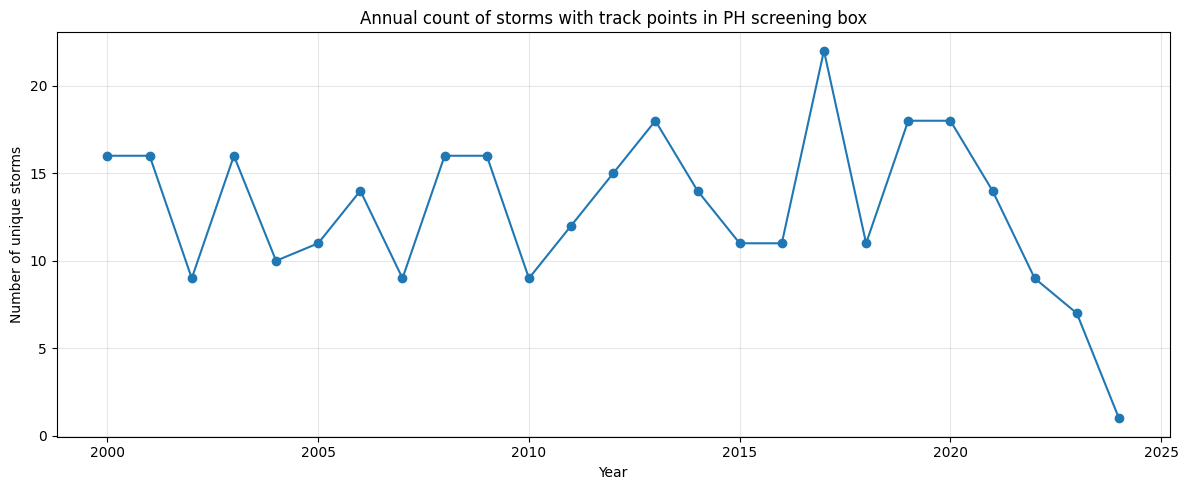

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(storms_per_year["year"], storms_per_year["n_storms_in_box"], marker="o")
ax.set_title("Annual count of storms with track points in PH screening box")
ax.set_xlabel("Year")
ax.set_ylabel("Number of unique storms")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

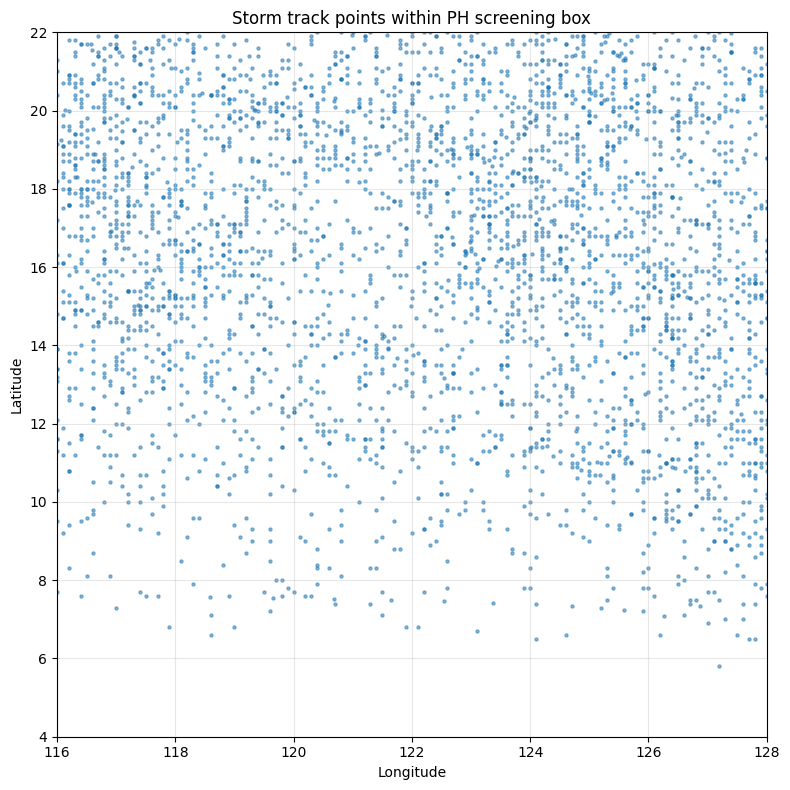

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ph_points["lon"], ph_points["lat"], s=5, alpha=0.5)
ax.set_xlim(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
ax.set_ylim(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Storm track points within PH screening box")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
top_storms_by_max_wind = (
    ph_storm_summary.sort_values(
        ["max_wind_kph_in_box", "year", "name"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
)
top_storms_by_max_wind.loc[
    :,
    [
        "storm_id",
        "name",
        "year",
        "n_points_in_box",
        "max_wind_kph_in_box",
        "mean_wind_kph_in_box",
    ],
].head(20)

,storm_id,name,year,n_points_in_box,max_wind_kph_in_box,mean_wind_kph_in_box
0,WP222020,GONI,2020,11,314.84,158.261818
1,WP162016,MERANTI,2016,6,314.84,299.406667
2,WP312013,HAIYAN,2013,6,314.84,260.823333
3,WP152010,MEGI,2010,22,296.32,210.875455
4,WP192021,CHANTHU,2021,11,287.06,250.020000
5,WP022021,SURIGAE,2021,20,287.06,216.221000
6,WP262018,MANGKHUT,2018,9,287.06,232.528889
7,WP022016,NEPARTAK,2016,5,287.06,268.540000
8,WP282021,RAI,2021,9,277.80,185.200000
9,WP262012,BOPHA,2012,21,277.80,149.041905


## Optional: export screened storm tables

In [ ]:
all_points_file = REPO_ROOT / f"ibtracs_west_pacific_all_points_since_{START_YEAR}.csv"
ph_points_file = REPO_ROOT / f"ibtracs_ph_screening_box_points_since_{START_YEAR}.csv"
ph_summary_file = REPO_ROOT / f"ibtracs_ph_screening_box_storm_summary_since_{START_YEAR}.csv"

all_points.to_csv(all_points_file, index=False)
ph_points.to_csv(ph_points_file, index=False)
ph_storm_summary.to_csv(ph_summary_file, index=False)

print("Saved:")
print(" ", all_points_file)
print(" ", ph_points_file)
print(" ", ph_summary_file)

Saved:
  /home/krawalker/coding/KRITIS-PH/ibtracs_west_pacific_all_points_since_2000.csv
  /home/krawalker/coding/KRITIS-PH/ibtracs_ph_screening_box_points_since_2000.csv
  /home/krawalker/coding/KRITIS-PH/ibtracs_ph_screening_box_storm_summary_since_2000.csv


## Population grid (WorldPop-style XYZ)

In [ ]:
def load_worldpop_xyz(path, verbose=True):
    try:
        df = pd.read_csv(path)
        if df.shape[1] < 3:
            raise ValueError("Too few columns from default CSV read.")
    except (pd.errors.ParserError, ValueError):
        df = pd.read_csv(
            path,
            sep=r"\s+",
            header=None,
            names=["c1", "c2", "c3"],
            comment="#",
            engine="python",
        )

    df.columns = [str(c).strip() for c in df.columns]
    if verbose:
        print("Raw columns:", list(df.columns))
        print(df.head())

    colmap = {str(c).strip().lower(): c for c in df.columns}

    def pick(candidates):
        for c in candidates:
            if c in colmap:
                return colmap[c]
        return None

    lon_col = pick(["lon", "longitude", "x"])
    lat_col = pick(["lat", "latitude", "y"])
    pop_col = pick(["pop_density", "population", "pop", "z", "value", "density"])

    if lon_col is None or lat_col is None or pop_col is None:
        if verbose:
            print("Falling back to first three columns.")
        first3 = list(df.columns)[:3]
        if len(first3) < 3:
            raise ValueError("Input file does not contain at least three columns.")
        lon_col, lat_col, pop_col = first3[0], first3[1], first3[2]

    out = df[[lon_col, lat_col, pop_col]].copy()
    out.columns = ["lon", "lat", "pop_value"]
    for c in ["lon", "lat", "pop_value"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna(subset=["lon", "lat", "pop_value"]).copy()
    if (out["lon"] < 0).any():
        out.loc[out["lon"] < 0, "lon"] = out.loc[out["lon"] < 0, "lon"] + 360
    return out


print("Population file:", XYZ_PATH)
worldpop = load_worldpop_xyz(XYZ_PATH, verbose=True)
print(f"Rows after cleaning: {len(worldpop):,}")
worldpop.head()

Population file: /home/krawalker/coding/KRITIS-PH/data/worldpop_ph_2020_1km/phl_pd_2020_1km_ASCII_XYZ.csv
Raw columns: ['X', 'Y', 'Z']
            X          Y          Z
0  121.927916  21.070417  11.426657
1  121.936250  21.070417   9.723458
2  121.927916  21.062083  10.262936
3  121.936250  21.062083   9.351555
4  121.911250  20.937083   8.565454
Rows after cleaning: 373,131


,lon,lat,pop_value
0,121.927916,21.070417,11.426657
1,121.936250,21.070417,9.723458
2,121.927916,21.062083,10.262936
3,121.936250,21.062083,9.351555
4,121.911250,20.937083,8.565454


In [ ]:
pop_ph = worldpop[
    worldpop["lat"].between(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
    & worldpop["lon"].between(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
    & (worldpop["pop_value"] > 0)
].copy()

print(f"Population rows in PH box: {len(pop_ph):,}")
print(f"Share of global rows retained: {len(pop_ph) / len(worldpop):.2%}")
pop_ph.head()

Population rows in PH box: 372,755
Share of global rows retained: 99.90%


,lon,lat,pop_value
0,121.927916,21.070417,11.426657
1,121.936250,21.070417,9.723458
2,121.927916,21.062083,10.262936
3,121.936250,21.062083,9.351555
4,121.911250,20.937083,8.565454


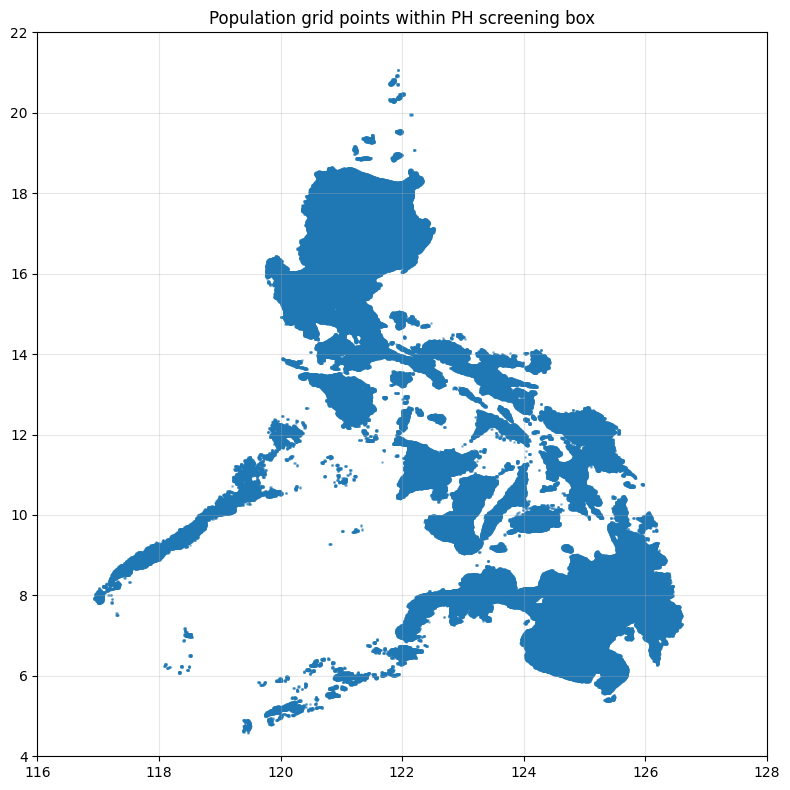

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pop_ph["lon"], pop_ph["lat"], s=1, alpha=0.4)
ax.set_xlim(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
ax.set_ylim(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
ax.set_title("Population grid points within PH screening box")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(pop_ph["pop_value"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

## PyPSA grid buses and composite bus weights

In [ ]:
buses = pd.read_csv(BUSES_CSV)
buses_v2 = buses.rename(columns={"name": "bus_id", "x": "lon", "y": "lat"}).copy()
for c in ["lon", "lat", "v_nom"]:
    buses_v2[c] = pd.to_numeric(buses_v2[c], errors="coerce")
buses_v2 = buses_v2.dropna(subset=["bus_id", "lon", "lat", "v_nom"]).copy()
print("buses_v2:", len(buses_v2))
buses_v2.head()

buses_v2: 192


,bus_id,lon,lat,v_nom
0,01AMBKLAO,120.741167,16.458580,230
1,01ANGAT,121.030976,14.922529,230
2,01ANGSJO_TP2,121.166303,14.907693,115
3,01ANGSJO_TP4,121.166303,14.907693,115
4,01BAKUN,120.823858,16.763519,230


In [ ]:
vmax = buses_v2["v_nom"].max()
if vmax <= 0:
    buses_v2["v_norm"] = 0.0
else:
    buses_v2["v_norm"] = buses_v2["v_nom"] / vmax
buses_v2["bus_weight_v"] = 1.0 + ALPHA_VNOM * buses_v2["v_norm"]
print("Voltage range:", buses_v2["v_nom"].min(), "to", buses_v2["v_nom"].max())
buses_v2[["bus_id", "v_nom", "v_norm", "bus_weight_v"]].head()

Voltage range: 69 to 500


,bus_id,v_nom,v_norm,bus_weight_v
0,01AMBKLAO,230,0.46,1.230
1,01ANGAT,230,0.46,1.230
2,01ANGSJO_TP2,115,0.23,1.115
3,01ANGSJO_TP4,115,0.23,1.115
4,01BAKUN,230,0.46,1.230


In [ ]:
pop_col = "pop_value"
bus_pop_vals = []
for _, b in buses_v2.iterrows():
    d = haversine_km(
        pop_ph["lat"].to_numpy(),
        pop_ph["lon"].to_numpy(),
        b["lat"],
        b["lon"],
    )
    local_pop = pop_ph.loc[d <= BUS_POP_RADIUS_KM, pop_col].sum()
    bus_pop_vals.append(local_pop)

buses_v2["bus_pop_local"] = bus_pop_vals
pmax = buses_v2["bus_pop_local"].max()
if pmax <= 0:
    buses_v2["bus_pop_norm"] = 0.0
else:
    buses_v2["bus_pop_norm"] = buses_v2["bus_pop_local"] / pmax

print("Computed population weights for", len(buses_v2), "buses")
buses_v2[["bus_id", "bus_pop_local", "bus_pop_norm"]].head()

Computed population weights for 192 buses


,bus_id,bus_pop_local,bus_pop_norm
0,01AMBKLAO,3.005067e+06,0.092133
1,01ANGAT,2.487936e+07,0.762781
2,01ANGSJO_TP2,2.340978e+07,0.717725
3,01ANGSJO_TP4,2.340978e+07,0.717725
4,01BAKUN,2.150979e+06,0.065947


In [ ]:
buses_v2["bus_weight_pop"] = 1.0 + buses_v2["bus_pop_norm"]
buses_v2["bus_weight"] = buses_v2["bus_weight_v"] * buses_v2["bus_weight_pop"]

display(
    buses_v2[
        ["bus_id", "bus_weight_v", "bus_pop_norm", "bus_weight_pop", "bus_weight"]
    ]
    .sort_values("bus_weight", ascending=False)
    .head(10)
)

,bus_id,bus_weight_v,bus_pop_norm,bus_weight_pop,bus_weight
71,03DASMAEHV,1.50,0.925199,1.925199,2.887799
26,01EHVSJOS,1.50,0.855578,1.855578,2.783367
75,03INGRID,1.50,0.843590,1.843590,2.765386
58,02MUNTINLUPA,1.23,1.000000,2.000000,2.460000
60,02ZAPOTE,1.23,0.999807,1.999807,2.459763
57,02MANILA,1.23,0.995193,1.995193,2.454087
56,02DONAIMELDA,1.23,0.989755,1.989755,2.447399
55,02DOLORES,1.23,0.984184,1.984184,2.440547
65,03BINAN,1.23,0.975683,1.975683,2.430091
59,02QUEZON,1.23,0.974372,1.974372,2.428477


## Module 3 — Network-adjusted bus weights

Uses **`lines.csv`** (graph degree) and **`generators.csv`** (capacity per bus). Redundancy: higher **degree** slightly **reduces** the marginal weight; **generation** slightly **increases** it. The composite **`bus_weight`** used below is overwritten; a copy is kept as **`bus_weight_pre_network**`.

In [ ]:
# Graph + capacity factors -> bus_weight (canonical pipeline uses this)
lines_net = pd.read_csv(LINES_CSV)
gens = pd.read_csv(GENERATORS_CSV)

buses_v2["bus_weight_pre_network"] = buses_v2["bus_weight"].copy()

deg = pd.concat([lines_net["bus0"], lines_net["bus1"]]).value_counts()
deg_series = buses_v2["bus_id"].map(deg).fillna(0).astype(float)
redundancy = np.sqrt(2.0 / np.maximum(deg_series.to_numpy(), 1.0))

cap_by_bus = gens.groupby("bus")["p_nom"].sum()
cap = buses_v2["bus_id"].map(cap_by_bus).fillna(0.0).to_numpy()
cmax = float(np.max(cap)) if len(cap) else 0.0
gen_norm = cap / cmax if cmax > 0 else np.zeros_like(cap)

w_deg = 1.0 - ALPHA_NET_DEG + ALPHA_NET_DEG * redundancy
w_gen = 1.0 + ALPHA_NET_GEN * gen_norm
buses_v2["graph_degree"] = deg_series.to_numpy()
buses_v2["bus_weight"] = buses_v2["bus_weight_pre_network"].to_numpy() * w_deg * w_gen

print(
    "bus_weight: pre-network mean",
    f"{buses_v2['bus_weight_pre_network'].mean():.4f},",
    "after network mean",
    f"{buses_v2['bus_weight'].mean():.4f}",
)
display(buses_v2[["bus_id", "graph_degree", "bus_weight_pre_network", "bus_weight"]].nlargest(10, "bus_weight"))


bus_weight: pre-network mean 1.4746, after network mean 1.4900


,bus_id,graph_degree,bus_weight_pre_network,bus_weight
75,03INGRID,1.0,2.765386,2.959346
71,03DASMAEHV,4.0,2.887799,2.765491
60,02ZAPOTE,1.0,2.459763,2.612593
26,01EHVSJOS,10.0,2.783367,2.552575
58,02MUNTINLUPA,2.0,2.460000,2.460000
55,02DOLORES,2.0,2.440547,2.455902
57,02MANILA,2.0,2.454087,2.454087
56,02DONAIMELDA,2.0,2.447399,2.447399
13,01BPC,1.0,2.274296,2.415603
92,03STROSA,2.0,2.411562,2.411562


**Methods — canonical ranking.** `compute_event_rankings`: per bus, max wind-based hazard over track times within `SEARCH_RADIUS_KM`, decay `DECAY_KM`, times `bus_weight`; storm score = sum over buses. Outputs `storm_rank_v2`, `bus_event_df`. Re-run if radii, weights, buses, or points change.

## Canonical ranking: `impact_score`

In [ ]:
def compute_event_rankings(
    ph_points_df,
    buses_df,
    search_radius_km,
    decay_km,
    wind_norm_mode="global_max",
    name_map=None,
):
    """
    V2-style event rankings:
    - hazard at each bus from each storm time step
    - max-over-time hazard at each bus
    - weighted sum across buses -> impact_score
    """
    if name_map is None:
        name_map = {}
    if ph_points_df.empty:
        raise ValueError("ph_points_df is empty.")
    if buses_df.empty:
        raise ValueError("buses_df is empty.")
    if search_radius_km <= 0:
        raise ValueError("search_radius_km must be positive.")
    if decay_km <= 0:
        raise ValueError("decay_km must be positive.")

    max_wind_global = ph_points_df["wind_kph"].max()
    if pd.isna(max_wind_global) or max_wind_global <= 0:
        max_wind_global = 1.0

    bus_lat = buses_df["lat"].to_numpy()
    bus_lon = buses_df["lon"].to_numpy()
    bus_id_arr = buses_df["bus_id"].to_numpy()
    bus_w_arr = buses_df["bus_weight"].to_numpy()

    bus_event_rows = []

    for storm_id, sgrp in ph_points_df.groupby("storm_id"):
        hazard_max = np.zeros(len(buses_df), dtype=float)

        if wind_norm_mode == "storm_max":
            storm_max = sgrp["wind_kph"].max()
            if pd.isna(storm_max) or storm_max <= 0:
                storm_max = 1.0
        else:
            storm_max = max_wind_global

        for _, sp in sgrp.iterrows():
            d = haversine_km(bus_lat, bus_lon, sp["lat"], sp["lon"])
            near = d <= search_radius_km
            if not np.any(near):
                continue

            wind_norm = float(sp["wind_kph"] / storm_max)
            hz = wind_norm * np.exp(-d[near] / decay_km)

            hazard_max[near] = np.maximum(hazard_max[near], hz)

        storm_year = sgrp["year"].min() if "year" in sgrp.columns else np.nan

        for i in range(len(buses_df)):
            bus_event_rows.append(
                {
                    "storm_id": storm_id,
                    "year": storm_year,
                    "bus_id": bus_id_arr[i],
                    "hazard_max": float(hazard_max[i]),
                    "bus_weight": float(bus_w_arr[i]),
                    "impact_bus": float(hazard_max[i] * bus_w_arr[i]),
                }
            )

    bus_event_df = pd.DataFrame(bus_event_rows)

    storm_rank = (
        bus_event_df.groupby("storm_id", as_index=False)
        .agg(
            impact_score=("impact_bus", "sum"),
            max_hazard=("hazard_max", "max"),
            mean_hazard=("hazard_max", "mean"),
            impacted_buses=("hazard_max", lambda x: int((x > 0).sum())),
            mean_bus_weight_impacted=(
                "bus_weight",
                lambda x: float(np.mean(x)) if len(x) else np.nan,
            ),
        )
    )

    if "year" in bus_event_df.columns:
        year_map = bus_event_df.groupby("storm_id", as_index=False)["year"].min()
        storm_rank = storm_rank.merge(year_map, on="storm_id", how="left")

    storm_rank["storm_name"] = storm_rank["storm_id"].map(name_map).fillna("UNNAMED")
    storm_rank = storm_rank.sort_values("impact_score", ascending=False).reset_index(drop=True)
    storm_rank["rank"] = storm_rank.index + 1

    return storm_rank, bus_event_df

name_map = storm_name_map_from_ib(ib)

ph_points_v2 = ph_points.copy()
if "t" not in ph_points_v2.columns:
    ph_points_v2 = ph_points_v2.sort_values(["storm_id"]).copy()
    ph_points_v2["t"] = ph_points_v2.groupby("storm_id").cumcount()
if "year" not in ph_points_v2.columns:
    ph_points_v2["year"] = np.nan

storm_rank_v2, bus_event_df = compute_event_rankings(
    ph_points_v2,
    buses_v2,
    SEARCH_RADIUS_KM,
    DECAY_KM,
    name_map=name_map,
)

print("Ranked storms:", len(storm_rank_v2))
display(
    storm_rank_v2[
        [
            "rank",
            "storm_id",
            "storm_name",
            "year",
            "impact_score",
            "max_hazard",
            "mean_hazard",
            "impacted_buses",
        ]
    ].head(20)
)



Ranked storms: 323


,rank,storm_id,storm_name,year,impact_score,max_hazard,mean_hazard,impacted_buses
0,1,WP182006,XANGSANE,2006,18.795306,0.483497,0.055584,82
1,2,WP072008,FENGSHEN,2008,16.209838,0.299742,0.046235,117
2,3,WP312000,BEBINCA,2000,14.236041,0.335155,0.038207,74
3,4,WP302000,XANGSANE,2000,14.213883,0.325112,0.040667,86
4,5,WP262022,NALGAE,2022,13.327787,0.187708,0.038122,87
5,6,WP222020,GONI,2020,12.112665,0.624989,0.034922,67
6,7,WP092014,RAMMASUN,2014,10.928688,0.412036,0.031721,70
7,8,WP182022,NORU,2022,9.853338,0.511801,0.028917,76
8,9,WP132002,UNNAMED,2002,9.491433,0.152019,0.026195,106
9,10,WP182021,CONSON,2021,8.078017,0.209223,0.024547,85


### Land-only vs box ranking (Module 1)

**Results —** Compare ranks when restricting to **on-land** points; Spearman vs the full-box baseline summarizes sensitivity to ocean points in the domain.

Same `compute_event_rankings` and bus weights, but track points restricted to **on-land** observations. **Spearman** compares storm ranks to the baseline (all box points).

In [ ]:
# Land-only ranking vs baseline (box can include ocean points in the domain)
ph_points_v2_land = ph_points_land.copy()
if len(ph_points_v2_land) == 0:
    raise ValueError("No on-land track points; check Natural Earth / coordinates.")

if "t" not in ph_points_v2_land.columns:
    ph_points_v2_land = ph_points_v2_land.sort_values(["storm_id"]).copy()
    ph_points_v2_land["t"] = ph_points_v2_land.groupby("storm_id").cumcount()
if "year" not in ph_points_v2_land.columns:
    ph_points_v2_land["year"] = np.nan

storm_rank_land, bus_event_land = compute_event_rankings(
    ph_points_v2_land,
    buses_v2,
    SEARCH_RADIUS_KM,
    DECAY_KM,
    name_map=name_map,
)

rank_compare = storm_rank_v2[["storm_id", "rank", "impact_score"]].merge(
    storm_rank_land[["storm_id", "rank", "impact_score"]],
    on="storm_id",
    how="inner",
    suffixes=("_box", "_land"),
)

rho, _p = spearmanr(rank_compare["rank_box"], rank_compare["rank_land"])
print(
    "Spearman rho (storm rank, box points vs land-only points):",
    f"{rho:.3f}",
    f"(N={len(rank_compare)} storms with ≥1 land point)",
)
display(rank_compare.sort_values("rank_box").head(20))


Spearman rho (storm rank, box points vs land-only points): 0.924 (N=126 storms with ≥1 land point)


,storm_id,rank_box,impact_score_box,rank_land,impact_score_land
0,WP182006,1,18.795306,1,19.038875
1,WP072008,2,16.209838,2,15.340869
2,WP312000,3,14.236041,3,14.096639
3,WP302000,4,14.213883,8,7.733306
4,WP262022,5,13.327787,4,13.458562
5,WP222020,6,12.112665,5,12.164729
6,WP092014,7,10.928688,19,4.193053
7,WP182022,8,9.853338,6,9.322839
8,WP132002,9,9.491433,7,9.077787
9,WP182021,10,8.078017,11,6.415498


**Methods — map.** Cartopy basemap; population sample, tracks, and/or top-ranked storm tracks vs buses.

## Map: population, all screened tracks, buses

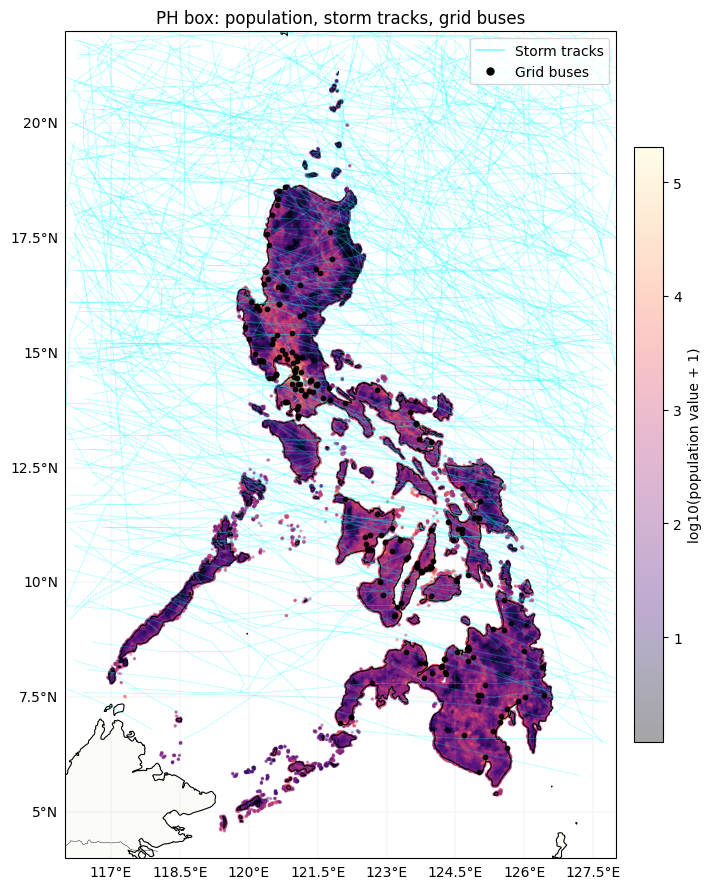

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

plot_pop = pop_ph.sample(
    min(len(pop_ph), POP_PLOT_SAMPLE_N), random_state=RANDOM_SEED
).copy()
plot_pop["log_pop_value"] = np.log10(plot_pop["pop_value"] + 1.0)
storm_groups = list(
    ph_points.sort_values(["storm_id", "point_index"]).groupby("storm_id")
)

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [
        PH_BOUNDS["lon_min"],
        PH_BOUNDS["lon_max"],
        PH_BOUNDS["lat_min"],
        PH_BOUNDS["lat_max"],
    ],
    crs=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    plot_pop["lon"],
    plot_pop["lat"],
    c=plot_pop["log_pop_value"],
    s=2,
    alpha=0.35,
    cmap="magma",
    transform=ccrs.PlateCarree(),
    zorder=1,
)
for _, grp in storm_groups:
    if len(grp) >= 2:
        ax.plot(
            grp["lon"],
            grp["lat"],
            linewidth=0.7,
            alpha=0.25,
            color="cyan",
            transform=ccrs.PlateCarree(),
            zorder=2,
        )

ax.scatter(
    buses_v2["lon"],
    buses_v2["lat"],
    s=10,
    color="black",
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("log10(population value + 1)")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
gl.top_labels = False
gl.right_labels = False

legend_handles = [
    Line2D([0], [0], color="cyan", lw=1.2, alpha=0.5, label="Storm tracks"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linestyle="None",
        markersize=5,
        label="Grid buses",
    ),
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_title("PH box: population, storm tracks, grid buses")
plt.tight_layout()
plt.show()

**Methods — map.** Cartopy basemap; population sample, tracks, and/or top-ranked storm tracks vs buses.

## Map: top-ranked storms by `impact_score`

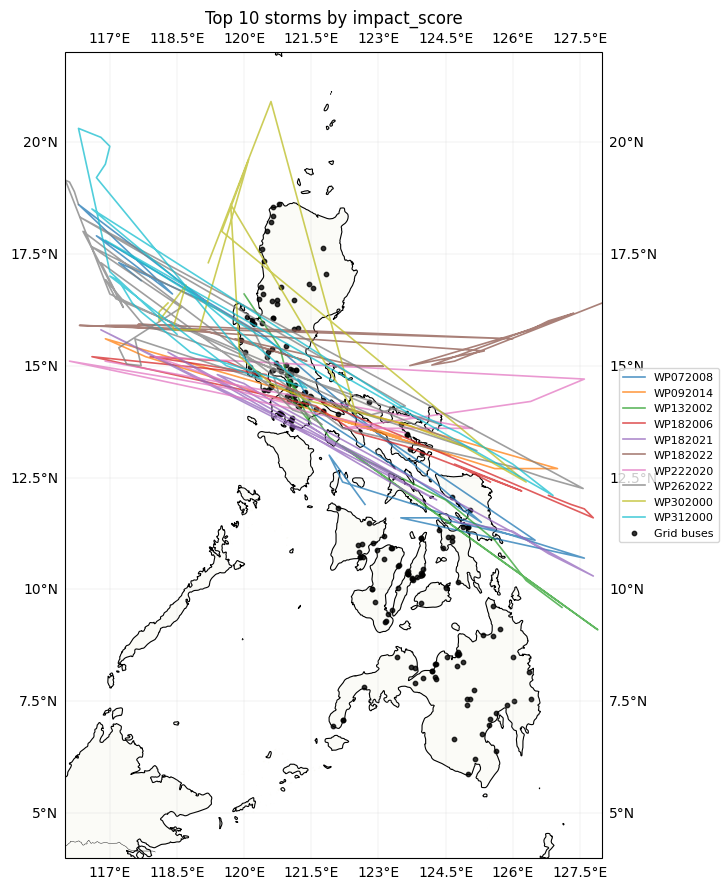

In [ ]:
top_n = 10
top_ids = storm_rank_v2.head(top_n)["storm_id"].tolist()
top_tracks = ph_points_v2[ph_points_v2["storm_id"].isin(top_ids)].copy()

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"], PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"]],
    crs=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

for sid, grp in top_tracks.sort_values(["storm_id", "t"]).groupby("storm_id"):
    ax.plot(
        grp["lon"],
        grp["lat"],
        linewidth=1.2,
        alpha=0.75,
        transform=ccrs.PlateCarree(),
        label=sid,
    )

ax.scatter(
    buses_v2["lon"],
    buses_v2["lat"],
    s=10,
    color="black",
    alpha=0.8,
    transform=ccrs.PlateCarree(),
    label="Grid buses",
)
ax.set_title(f"Top {top_n} storms by impact_score")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

**Methods — export.** Writes `outputs/storm_rank_v2.csv` for downstream use.

## Export ranking

In [ ]:
OUTPUT_DIR.mkdir(exist_ok=True)
out_csv = OUTPUT_DIR / "storm_rank_v2.csv"
storm_rank_v2.to_csv(out_csv, index=False)
print("Saved:", out_csv)

Saved: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_v2.csv


**Methods — secondary indices.** Storm-level vortex, coastal-wind, and rain-proxy metrics merged with `storm_rank_v2` for association checks (screening-only).

## Convergent hazard proxies (vs `impact_score`)

**Not** a damage model. Three extra storm-level metrics for comparison to **`impact_score`**:

1. **`vortex_impact_score`** — axisymmetric wind decay from each track point to each bus (`Vmax × R/(r+R)`), **max over time** per bus, then **sum** of `hazard × bus_weight` (same weights as baseline).
2. **`coastal_wind_proxy`** — for **on-land** points only: sum of `wind_kph × exp(-dist_to_coast_km / scale)` (needs Module 1 columns).
3. **`rain_proxy_sum`** — crude sum of **`wind_kt`** along the track in the box (intensity surrogate, not meteorological rain).

Spearman correlation vs **`impact_score`** is printed below.

In [ ]:
# --- Vortex-style hazard (same bus weights as baseline) ---
max_w = float(ph_points_v2["wind_kph"].max())
if max_w <= 0 or np.isnan(max_w):
    max_w = 1.0

bus_lat = buses_v2["lat"].to_numpy()
bus_lon = buses_v2["lon"].to_numpy()
bus_w = buses_v2["bus_weight"].to_numpy()


def _vortex_wind_kph(d_km, vmax_kph, r_mw_km):
    d = np.maximum(np.asarray(d_km, dtype=float), 0.0)
    return vmax_kph * (r_mw_km / (d + r_mw_km))


vortex_rows = []
for storm_id, sgrp in ph_points_v2.groupby("storm_id"):
    hmax = np.zeros(len(buses_v2), dtype=float)
    for _, sp in sgrp.iterrows():
        d = haversine_km(bus_lat, bus_lon, sp["lat"], sp["lon"])
        v = _vortex_wind_kph(d, float(sp["wind_kph"]), VORTEX_R_MW_KM)
        v = np.where(d <= VORTEX_SEARCH_KM, v, 0.0)
        vn = v / max_w
        hmax = np.maximum(hmax, vn)
    vortex_rows.append(
        {"storm_id": storm_id, "vortex_impact_score": float(np.sum(hmax * bus_w))}
    )

vortex_df = pd.DataFrame(vortex_rows)

# --- Coastal wind proxy (Module 1 land + coast distance) ---
if {"on_land", "dist_to_coast_km"}.issubset(ph_points_v2.columns):
    tmp = ph_points_v2.copy()
    w = np.where(
        tmp["on_land"],
        tmp["wind_kph"].to_numpy()
        * np.exp(-tmp["dist_to_coast_km"].to_numpy() / COAST_WIND_SCALE_KM),
        0.0,
    )
    coastal_by_storm = tmp.assign(_cw=w).groupby("storm_id", as_index=False)["_cw"].sum()
    coastal_by_storm = coastal_by_storm.rename(columns={"_cw": "coastal_wind_proxy"})
else:
    coastal_by_storm = pd.DataFrame(columns=["storm_id", "coastal_wind_proxy"])
    print("Skip coastal_wind_proxy: run Module 1 land mask first (on_land / dist_to_coast_km).")

# --- Rain proxy: sum wind_kt along track ---
pt = ph_points_v2.copy()
if "wind_kt" not in pt.columns:
    pt["wind_kt"] = pt["wind_kph"] / 1.852
rain_df = pt.groupby("storm_id", as_index=False)["wind_kt"].sum().rename(
    columns={"wind_kt": "rain_proxy_sum"}
)

hazard_extras = (
    storm_rank_v2[["storm_id", "rank", "impact_score"]]
    .merge(vortex_df, on="storm_id", how="left")
    .merge(coastal_by_storm, on="storm_id", how="left")
    .merge(rain_df, on="storm_id", how="left")
)

for col in ("coastal_wind_proxy",):
    if col in hazard_extras.columns:
        hazard_extras[col] = hazard_extras[col].fillna(0.0)

display(hazard_extras.sort_values("rank").head(20))

m = hazard_extras.dropna(subset=["vortex_impact_score", "impact_score"])
if len(m) > 2:
    r1, _ = spearmanr(m["impact_score"], m["vortex_impact_score"])
    print(f"Spearman(impact_score, vortex_impact_score) = {r1:.3f}  (N={len(m)})")
if {"coastal_wind_proxy"}.issubset(hazard_extras.columns) and hazard_extras["coastal_wind_proxy"].sum() > 0:
    m2 = hazard_extras[hazard_extras["coastal_wind_proxy"] > 0]
    if len(m2) > 2:
        r2, _ = spearmanr(m2["impact_score"], m2["coastal_wind_proxy"])
        print(f"Spearman(impact_score, coastal_wind_proxy) = {r2:.3f}  (N={len(m2)})")
m3 = hazard_extras.dropna(subset=["rain_proxy_sum", "impact_score"])
if len(m3) > 2:
    r3, _ = spearmanr(m3["impact_score"], m3["rain_proxy_sum"])
    print(f"Spearman(impact_score, rain_proxy_sum) = {r3:.3f}  (N={len(m3)})")


,storm_id,rank,impact_score,vortex_impact_score,coastal_wind_proxy,rain_proxy_sum
0,WP182006,1,18.795306,52.608516,729.791366,1190.0
1,WP072008,2,16.209838,45.923758,420.537346,1245.0
2,WP312000,3,14.236041,35.325215,235.685099,1320.0
3,WP302000,4,14.213883,33.104755,88.068713,1320.0
4,WP262022,5,13.327787,27.544592,572.566707,1750.0
5,WP222020,6,12.112665,29.733041,303.268271,940.0
6,WP092014,7,10.928688,37.402171,360.605009,820.0
7,WP182022,8,9.853338,38.589425,502.042954,1890.0
8,WP132002,9,9.491433,19.864492,213.049991,445.0
9,WP182021,10,8.078017,27.311302,288.733473,790.0


Spearman(impact_score, vortex_impact_score) = 0.927  (N=322)
Spearman(impact_score, coastal_wind_proxy) = 0.632  (N=126)
Spearman(impact_score, rain_proxy_sum) = 0.443  (N=323)


## Validation and external association

Three layers:
1. **Internal (Module 4)** — Precision@k for known storm IDs; placebo rank correlations.
2. **Interpretation (priority / land–sea)** — Share of score from on-land vs in-box offshore points; event-study table.
3. **External association** — Benchmark table plus Spearman / scatter vs `storm_validation_master.csv` (not causal).


**Methods — internal validation.** Precision@k against a hand list of storm IDs; placebo Spearman by shuffling scores. Tables that use **`rank_summary`** (mean rank across the parameter grid) appear **after the robustness appendix**.

### Module 4 — Internal validation (precision@k, placebo)

**Known storm IDs** are a small hand list (verify against your IBTrACS extract). **Precision@k** uses **`storm_rank_v2`** ordering. **Placebo** shuffles **`impact_score`** values among storms and re-ranks; mean Spearman vs truth should be near **0**.

The next cell defines **`precision_at_k`** locally so you can run validation without re-running **Helpers**.


In [ ]:
def precision_at_k(ranked_ids: list, positive_ids: set, k: int) -> float:
    if k <= 0 or not ranked_ids:
        return 0.0
    top = ranked_ids[:k]
    return sum(1 for sid in top if sid in positive_ids) / min(k, len(top))


KNOWN_MAJOR_STORM_IDS = {
    "WP182006",
    "WP242013",
    "WP262012",
    "WP302021",
    "WP192020",
}

ranked = storm_rank_v2["storm_id"].tolist()
print("Precision@k (fraction of top-k that are in known-major ID set):")
for k in (5, 10, 20):
    print(f"  k={k:2d}: {precision_at_k(ranked, KNOWN_MAJOR_STORM_IDS, k):.3f}")

rng = np.random.default_rng(RANDOM_SEED)
placebo_rhos = []
for _ in range(PLACEBO_N):
    df = storm_rank_v2.copy()
    scores = df["impact_score"].to_numpy().copy()
    rng.shuffle(scores)
    df["_s"] = scores
    df = df.sort_values("_s", ascending=False).reset_index(drop=True)
    df["rank_p"] = df.index + 1
    m = storm_rank_v2[["storm_id", "rank"]].merge(df[["storm_id", "rank_p"]], on="storm_id")
    placebo_rhos.append(spearmanr(m["rank"], m["rank_p"])[0])

print(f"Placebo: mean Spearman(rank, rank_after_shuffle) over {PLACEBO_N} draws: {np.mean(placebo_rhos):.4f} (expect ~0)")


Precision@k (fraction of top-k that are in known-major ID set):
  k= 5: 0.200
  k=10: 0.100
  k=20: 0.050
Placebo: mean Spearman(rank, rank_after_shuffle) over 30 draws: 0.0197 (expect ~0)


**Methods — land vs sea.** Separate rankings for on-land vs offshore-in-box points; `land_share_of_split`; CSV export and two-panel figure.

### Priority analysis — land vs sea, event study, flagship figure

**Land vs sea:** separate **`compute_event_rankings`** on **on-land** vs **offshore (in-box)** track points; **`land_share_of_split`** = land-only score / (land + sea) when the sum is positive (screening geometry, not energy balance).

**Event study:** hand-curated **`EVENT_NOTES`** (edit in code) — merge with ranks for external-validation narrative; add loss columns when you have data.

**Figure:** top storms by **`impact_score`** vs **`land_share_of_split`** (requires Module 1).

Spearman(impact_score, land_share_of_split): 0.489 (N=178)


,storm_id,storm_name,year,rank,impact_score,impact_land_only,impact_sea_only,land_share_of_split
0,WP182006,XANGSANE,2006,1,18.795306,19.038875,1.109083,0.944953
1,WP072008,FENGSHEN,2008,2,16.209838,15.340869,1.949307,0.887259
2,WP312000,BEBINCA,2000,3,14.236041,14.096639,1.579339,0.899251
3,WP302000,XANGSANE,2000,4,14.213883,7.733306,9.245537,0.455467
4,WP262022,NALGAE,2022,5,13.327787,13.458562,2.223948,0.858189
5,WP222020,GONI,2020,6,12.112665,12.164729,1.068213,0.919276
6,WP092014,RAMMASUN,2014,7,10.928688,4.193053,7.916340,0.346265
7,WP182022,NORU,2022,8,9.853338,9.322839,1.875015,0.832556
8,WP132002,UNNAMED,2002,9,9.491433,9.077787,2.336755,0.795283
9,WP182021,CONSON,2021,10,8.078017,6.415498,3.777061,0.629430


,storm_id,in_screened_sample,rank,impact_score,land_share,name,tier,ref
0,WP182006,True,1.0,18.795306,0.944953,XANGSANE,major,2006 Luzon; verify impacts in EM-DAT/PAGASA
1,WP242013,True,24.0,4.427597,0.923258,HAIYAN,catastrophic,2013; extreme wind/surge — verify IBTrACS id
2,WP262012,True,35.0,3.009576,0.348042,BOPHA,severe,Mindanao/Pablo
4,WP192020,True,80.0,1.061846,0.000000,GONI,severe,2020 Rolly
3,WP302021,False,NaN,NaN,NaN,RAI,severe,2021 Odette
5,WP312020,False,NaN,NaN,NaN,VAMCO,major,2020 Ulysses flooding
6,WP212006,False,NaN,NaN,NaN,DURIAN,severe,2006 Reming/Bicol


Saved /home/krawalker/coding/KRITIS-PH/outputs/geo_land_sea_scores.csv


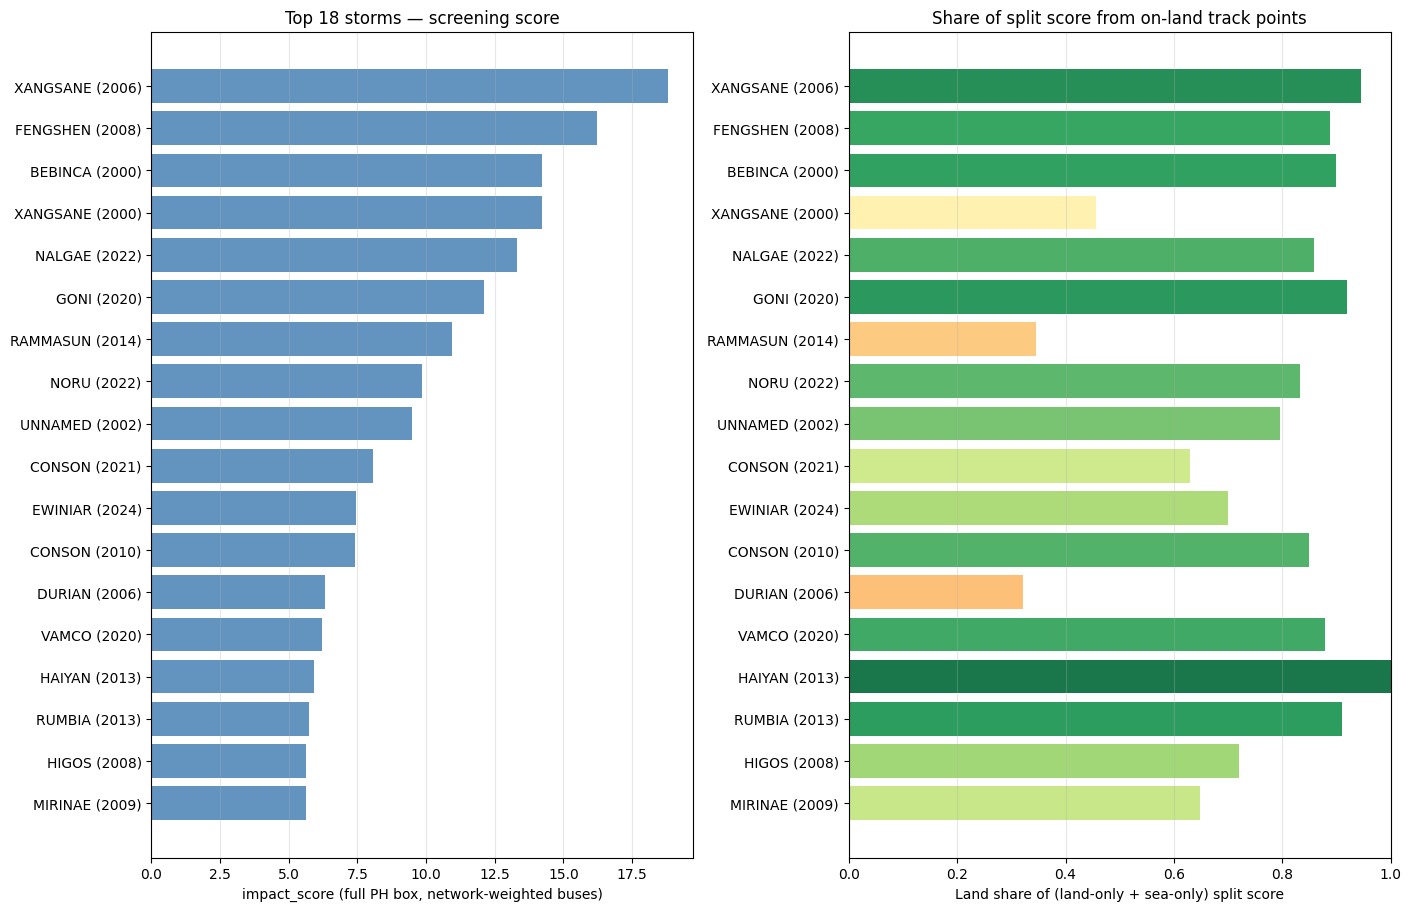

In [ ]:
# --- Land vs sea decomposition of screening scores (Module 1 required) ---
if "on_land" not in ph_points.columns:
    raise ValueError("Run Module 1 (land mask) before this cell.")

ph_points_sea = ph_points.loc[~ph_points["on_land"]].copy()
ph_points_v2_sea = ph_points_sea.sort_values(["storm_id"]).copy()
ph_points_v2_sea["t"] = ph_points_v2_sea.groupby("storm_id").cumcount()
if "year" not in ph_points_v2_sea.columns:
    ph_points_v2_sea["year"] = np.nan

if len(ph_points_v2_sea) == 0:
    storm_rank_sea = pd.DataFrame(columns=["storm_id", "impact_score", "rank"])
    print("No offshore track points in PH box; impact_sea_only will be 0 for all storms.")
else:
    storm_rank_sea, _ = compute_event_rankings(
        ph_points_v2_sea, buses_v2, SEARCH_RADIUS_KM, DECAY_KM, name_map=name_map
    )

geo_val = (
    storm_rank_v2[["storm_id", "storm_name", "year", "rank", "impact_score"]]
    .merge(
        storm_rank_land[["storm_id", "impact_score"]].rename(
            columns={"impact_score": "impact_land_only"}
        ),
        on="storm_id",
        how="left",
    )
    .merge(
        storm_rank_sea[["storm_id", "impact_score"]].rename(
            columns={"impact_score": "impact_sea_only"}
        ),
        on="storm_id",
        how="left",
    )
)
geo_val["impact_land_only"] = geo_val["impact_land_only"].fillna(0.0)
geo_val["impact_sea_only"] = geo_val["impact_sea_only"].fillna(0.0)
_tot = geo_val["impact_land_only"] + geo_val["impact_sea_only"]
geo_val["land_share_of_split"] = np.where(
    _tot > 0, geo_val["impact_land_only"] / _tot, np.nan
)

_gv = geo_val.dropna(subset=["land_share_of_split", "impact_score"])
if len(_gv) > 2:
    _r, _ = spearmanr(_gv["impact_score"], _gv["land_share_of_split"])
    print(f"Spearman(impact_score, land_share_of_split): {_r:.3f} (N={len(_gv)})")
else:
    print("Not enough rows for Spearman (land/sea split).")
display(geo_val.head(25))

# --- Event study rows (edit IMPACT_NOTES; add loss_USD etc. when you have external data) ---
IMPACT_NOTES = {
    "WP182006": {"name": "XANGSANE", "tier": "major", "ref": "2006 Luzon; verify impacts in EM-DAT/PAGASA"},
    "WP242013": {"name": "HAIYAN", "tier": "catastrophic", "ref": "2013; extreme wind/surge — verify IBTrACS id"},
    "WP262012": {"name": "BOPHA", "tier": "severe", "ref": "Mindanao/Pablo"},
    "WP302021": {"name": "RAI", "tier": "severe", "ref": "2021 Odette"},
    "WP192020": {"name": "GONI", "tier": "severe", "ref": "2020 Rolly"},
    "WP312020": {"name": "VAMCO", "tier": "major", "ref": "2020 Ulysses flooding"},
    "WP212006": {"name": "DURIAN", "tier": "severe", "ref": "2006 Reming/Bicol"},
}

es_rows = []
for sid, meta in IMPACT_NOTES.items():
    hit = storm_rank_v2.loc[storm_rank_v2["storm_id"] == sid]
    if len(hit) == 0:
        es_rows.append(
            {
                "storm_id": sid,
                "in_screened_sample": False,
                "rank": np.nan,
                "impact_score": np.nan,
                "land_share": np.nan,
                **{k: meta[k] for k in ("name", "tier", "ref")},
            }
        )
        continue
    r = hit.iloc[0]
    gv = geo_val.loc[geo_val["storm_id"] == sid]
    ls = float(gv["land_share_of_split"].iloc[0]) if len(gv) else np.nan
    es_rows.append(
        {
            "storm_id": sid,
            "in_screened_sample": True,
            "rank": r["rank"],
            "impact_score": r["impact_score"],
            "land_share": ls,
            **{k: meta[k] for k in ("name", "tier", "ref")},
        }
    )
event_study = pd.DataFrame(es_rows).sort_values("rank", na_position="last")
display(event_study)

out_geo = OUTPUT_DIR / "geo_land_sea_scores.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
geo_val.to_csv(out_geo, index=False)
print("Saved", out_geo)

# --- Flagship figure: impact_score vs land share (top 18 by score) ---
topn = 18
top = geo_val.nlargest(topn, "impact_score").sort_values("impact_score", ascending=True)
labels = top["storm_name"] + " (" + top["year"].fillna(-1).astype(int).astype(str) + ")"
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 9), constrained_layout=True)
ax0.barh(labels, top["impact_score"], color="steelblue", alpha=0.85)
ax0.set_xlabel("impact_score (full PH box, network-weighted buses)")
ax0.set_title(f"Top {topn} storms — screening score")
ax0.grid(True, axis="x", alpha=0.3)

colors = plt.cm.RdYlGn(top["land_share_of_split"].fillna(0.5))
ax1.barh(labels, top["land_share_of_split"].fillna(0), color=colors, alpha=0.9)
ax1.set_xlim(0, 1)
ax1.set_xlabel("Land share of (land-only + sea-only) split score")
ax1.set_title("Share of split score from on-land track points")
ax1.grid(True, axis="x", alpha=0.3)
plt.show()


**Methods — benchmark table.** Merge `storm_rank_v2`, `ph_storm_summary`, optional `geo_val` / `hazard_extras`, and `data/storm_impact_benchmark_external.csv` → `outputs/storm_validation_benchmark.csv`.

### External validation benchmark table

**Purpose:** one row per screened storm merging **internal screening indices** with **external impact fields** so you can correlate or calibrate (Spearman, scatter, tier hit rates).

**External columns** are maintained in **`data/storm_impact_benchmark_external.csv`** (keyed by **`storm_id`**). Edit that file with EM-DAT, Desinventar, NDRRMC/PAGASA summaries, or power-sector reports; add **`grid_outage_proxy`** / **`restoration_proxy`** when you have customer-hours off, % generation offline, or restoration clocks.

If a storm is missing from the CSV, it still appears in the table with **NaN** externals. Re-run this cell after editing the CSV.

In [ ]:
# --- validation_benchmark_table: internal indices + external benchmark ---
BENCHMARK_EXTERNAL_CSV = REPO_ROOT / "data/storm_impact_benchmark_external.csv"

sum_part = ph_storm_summary[
    [
        "storm_id",
        "n_points_in_box",
        "max_wind_kph_in_box",
        "mean_wind_kph_in_box",
    ]
].copy()

validation_benchmark_table = storm_rank_v2.merge(sum_part, on="storm_id", how="left")

# Land/sea split (requires priority-analysis / geo_val)
if "geo_val" in dir() and geo_val is not None and len(geo_val):
    validation_benchmark_table = validation_benchmark_table.merge(
        geo_val[
            ["storm_id", "land_share_of_split", "impact_land_only", "impact_sea_only"]
        ],
        on="storm_id",
        how="left",
    )
else:
    validation_benchmark_table["land_share_of_split"] = np.nan
    validation_benchmark_table["impact_land_only"] = np.nan
    validation_benchmark_table["impact_sea_only"] = np.nan

# Module 2 proxies (optional)
if "hazard_extras" in dir() and hazard_extras is not None and len(hazard_extras):
    hx = hazard_extras[
        [
            "storm_id",
            "vortex_impact_score",
            "coastal_wind_proxy",
            "rain_proxy_sum",
        ]
    ].copy()
    validation_benchmark_table = validation_benchmark_table.merge(
        hx, on="storm_id", how="left"
    )

# External benchmark file (edit in spreadsheet / version control)
ext_cols = [
    "storm_id",
    "deaths",
    "affected_people",
    "damage_usd",
    "grid_outage_proxy",
    "restoration_proxy",
    "notes",
    "source",
]
if BENCHMARK_EXTERNAL_CSV.exists():
    ext_df = pd.read_csv(BENCHMARK_EXTERNAL_CSV)
    ext_df["storm_id"] = ext_df["storm_id"].astype(str)
    for c in ext_cols[1:]:
        if c not in ext_df.columns:
            ext_df[c] = np.nan
    ext_df = ext_df[ext_cols].drop_duplicates(subset=["storm_id"], keep="last")
else:
    ext_df = pd.DataFrame({"storm_id": validation_benchmark_table["storm_id"].astype(str)})
    for c in ext_cols[1:]:
        ext_df[c] = np.nan
    BENCHMARK_EXTERNAL_CSV.parent.mkdir(parents=True, exist_ok=True)
    ext_df.to_csv(BENCHMARK_EXTERNAL_CSV, index=False)
    print("Created empty template:", BENCHMARK_EXTERNAL_CSV)

validation_benchmark_table["storm_id"] = validation_benchmark_table["storm_id"].astype(str)
validation_benchmark_table = validation_benchmark_table.merge(
    ext_df, on="storm_id", how="left", suffixes=("", "_ext")
)

# Canonical column order (internal block then external block)
internal_front = [
    "storm_id",
    "storm_name",
    "year",
    "impact_score",
    "rank",
    "impacted_buses",
    "max_hazard",
    "mean_hazard",
    "land_share_of_split",
    "impact_land_only",
    "impact_sea_only",
    "max_wind_kph_in_box",
    "n_points_in_box",
    "mean_wind_kph_in_box",
]
optional_mid = [
    "vortex_impact_score",
    "coastal_wind_proxy",
    "rain_proxy_sum",
]
external_block = [
    "deaths",
    "affected_people",
    "damage_usd",
    "grid_outage_proxy",
    "restoration_proxy",
    "notes",
    "source",
]
ordered = [c for c in internal_front if c in validation_benchmark_table.columns]
ordered += [c for c in optional_mid if c in validation_benchmark_table.columns]
ordered += [c for c in external_block if c in validation_benchmark_table.columns]
rest = [c for c in validation_benchmark_table.columns if c not in ordered]
validation_benchmark_table = validation_benchmark_table[ordered + rest]

out_bench = OUTPUT_DIR / "storm_validation_benchmark.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
validation_benchmark_table.to_csv(out_bench, index=False)
print("Saved:", out_bench.resolve())
print("Rows:", len(validation_benchmark_table), "| External file:", BENCHMARK_EXTERNAL_CSV)

display(validation_benchmark_table.head(25))

# Quick view: storms with any external field filled
_ext = validation_benchmark_table[external_block]
has_any = _ext.notna().any(axis=1)
n_filled = int(has_any.sum())
print("Storms with at least one non-null external text/number column:", n_filled)
if n_filled:
    display(validation_benchmark_table.loc[has_any, ordered].head(20))


Saved: /home/krawalker/coding/KRITIS-PH/outputs/storm_validation_benchmark.csv
Rows: 323 | External file: /home/krawalker/coding/KRITIS-PH/data/storm_impact_benchmark_external.csv


,storm_id,storm_name,year,impact_score,rank,impacted_buses,max_hazard,mean_hazard,land_share_of_split,impact_land_only,...,coastal_wind_proxy,rain_proxy_sum,deaths,affected_people,damage_usd,grid_outage_proxy,restoration_proxy,notes,source,mean_bus_weight_impacted
0,WP182006,XANGSANE,2006,18.795306,1,82,0.483497,0.055584,0.944953,19.038875,...,729.791366,1190.0,200.0,3000000.0,1.000000e+08,NaN,NaN,Xangsane 2006,EM-DAT,1.490047
1,WP072008,FENGSHEN,2008,16.209838,2,117,0.299742,0.046235,0.887259,15.340869,...,420.537346,1245.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
2,WP312000,BEBINCA,2000,14.236041,3,74,0.335155,0.038207,0.899251,14.096639,...,235.685099,1320.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
3,WP302000,XANGSANE,2000,14.213883,4,86,0.325112,0.040667,0.455467,7.733306,...,88.068713,1320.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
4,WP262022,NALGAE,2022,13.327787,5,87,0.187708,0.038122,0.858189,13.458562,...,572.566707,1750.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
5,WP222020,GONI,2020,12.112665,6,67,0.624989,0.034922,0.919276,12.164729,...,303.268271,940.0,27.0,1500000.0,1.000000e+08,NaN,NaN,Molave/Quinta 2020,NDRRMC,1.490047
6,WP092014,RAMMASUN,2014,10.928688,7,70,0.412036,0.031721,0.346265,4.193053,...,360.605009,820.0,100.0,4000000.0,5.000000e+08,NaN,NaN,Rammasun/Glenda 2014,EM-DAT,1.490047
7,WP182022,NORU,2022,9.853338,8,76,0.511801,0.028917,0.832556,9.322839,...,502.042954,1890.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
8,WP132002,UNNAMED,2002,9.491433,9,106,0.152019,0.026195,0.795283,9.077787,...,213.049991,445.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047
9,WP182021,CONSON,2021,8.078017,10,85,0.209223,0.024547,0.629430,6.415498,...,288.733473,790.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.490047


Storms with at least one non-null external text/number column: 7


,storm_id,storm_name,year,impact_score,rank,impacted_buses,max_hazard,mean_hazard,land_share_of_split,impact_land_only,...,vortex_impact_score,coastal_wind_proxy,rain_proxy_sum,deaths,affected_people,damage_usd,grid_outage_proxy,restoration_proxy,notes,source
0,WP182006,XANGSANE,2006,18.795306,1,82,0.483497,0.055584,0.944953,19.038875,...,52.608516,729.791366,1190.0,200.0,3000000.0,1.000000e+08,NaN,NaN,Xangsane 2006,EM-DAT
5,WP222020,GONI,2020,12.112665,6,67,0.624989,0.034922,0.919276,12.164729,...,29.733041,303.268271,940.0,27.0,1500000.0,1.000000e+08,NaN,NaN,Molave/Quinta 2020,NDRRMC
6,WP092014,RAMMASUN,2014,10.928688,7,70,0.412036,0.031721,0.346265,4.193053,...,37.402171,360.605009,820.0,100.0,4000000.0,5.000000e+08,NaN,NaN,Rammasun/Glenda 2014,EM-DAT
23,WP242013,NARI,2013,4.427597,24,59,0.356428,0.014054,0.923258,4.520440,...,26.899438,83.793972,925.0,6300.0,16000000.0,1.300000e+10,NaN,NaN,Haiyan/Yolanda 2013,EM-DAT / NDRRMC
34,WP262012,BOPHA,2012,3.009576,35,49,0.203889,0.012540,0.348042,1.111350,...,22.375585,113.882162,1690.0,1900.0,6000000.0,1.000000e+09,NaN,NaN,Bopha/Pablo 2012,EM-DAT
74,WP272011,WASHI,2011,1.131117,75,43,0.096859,0.004795,0.426561,0.545771,...,8.714791,119.729257,405.0,1200.0,7000000.0,2.000000e+08,NaN,NaN,Washi/Sendong 2011,EM-DAT
79,WP192020,SAUDEL,2020,1.061846,80,31,0.153332,0.003828,0.000000,0.000000,...,10.046700,0.000000,605.0,25.0,2000000.0,2.000000e+08,NaN,NaN,Goni/Rolly 2020,PAGASA/NDRRMC


**Methods — external association.** Load master CSV (see candidate paths in code); Spearman vs deaths / damage / etc.; scatter `impact_score` vs `damage_usd`.

### Correlations vs `storm_validation_master.csv`

Place **`storm_validation_master.csv`** in **`outputs/`**, **`data/`**, or the repo root (first match wins; **`outputs/storm_validation_benchmark.csv`** is also accepted). It must include **`storm_id`** plus outcome columns such as **`deaths`**, **`affected_people`**, **`damage_usd`**, **`grid_outage_proxy`**.

This cell merges rankings with that file and with **`ph_storm_summary`** for naive baselines (**`max_wind_kph_in_box`**, **`n_points_in_box`**), then reports Spearman correlations and a scatter of **`impact_score`** vs **`damage_usd`** (labeled storms).

Loaded: /home/krawalker/coding/KRITIS-PH/data/storm_validation_master.csv
val rows: 323
val columns: ['storm_id', 'deaths', 'affected_people', 'damage_usd', 'grid_outage_proxy', 'restoration_proxy', 'notes', 'source', 'storm_name', 'year', 'impact_score', 'rank', 'impacted_buses', 'max_hazard', 'mean_hazard', 'land_share_of_split', 'impact_land_only', 'impact_sea_only', 'max_wind_kph_in_box', 'n_points_in_box', 'mean_wind_kph_in_box', 'vortex_impact_score', 'coastal_wind_proxy', 'rain_proxy_sum', 'mean_bus_weight_impacted']


,storm_id,deaths,affected_people,damage_usd,grid_outage_proxy,restoration_proxy,notes,source,storm_name,year,...,land_share_of_split,impact_land_only,impact_sea_only,max_wind_kph_in_box,n_points_in_box,mean_wind_kph_in_box,vortex_impact_score,coastal_wind_proxy,rain_proxy_sum,mean_bus_weight_impacted
0,WP182006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XANGSANE,2006,...,0.944953,19.038875,1.109083,231.50,14,157.420000,52.608516,729.791366,1190.0,1.490047
1,WP072008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FENGSHEN,2008,...,0.887259,15.340869,1.949307,203.72,17,135.631765,45.923758,420.537346,1245.0,1.490047
2,WP312000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BEBINCA,2000,...,0.899251,14.096639,1.579339,157.42,22,111.120000,35.325215,235.685099,1320.0,1.490047
3,WP302000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XANGSANE,2000,...,0.455467,7.733306,9.245537,166.68,18,135.813333,33.104755,88.068713,1320.0,1.490047
4,WP262022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NALGAE,2022,...,0.858189,13.458562,2.223948,129.64,33,98.212121,27.544592,572.566707,1750.0,1.490047


bench rows: 323
Non-null counts:
  impact_score: 323
  damage_usd: 22
  deaths: 22
  affected_people: 22
  grid_outage_proxy: 0
  restoration_proxy: 0


,storm_id,impact_score,max_hazard,mean_hazard,impacted_buses,mean_bus_weight_impacted,year,storm_name,rank,deaths,affected_people,damage_usd,grid_outage_proxy,restoration_proxy,notes,source,max_wind_kph_in_box,n_points_in_box,mean_wind_kph_in_box
0,WP182006,18.795306,0.483497,0.055584,82,1.490047,2006,XANGSANE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,231.50,14,157.420000
1,WP072008,16.209838,0.299742,0.046235,117,1.490047,2008,FENGSHEN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.72,17,135.631765
2,WP312000,14.236041,0.335155,0.038207,74,1.490047,2000,BEBINCA,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157.42,22,111.120000
3,WP302000,14.213883,0.325112,0.040667,86,1.490047,2000,XANGSANE,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166.68,18,135.813333
4,WP262022,13.327787,0.187708,0.038122,87,1.490047,2022,NALGAE,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,129.64,33,98.212121



Spearman vs impact_score:
deaths: Spearman = 0.076 (p=0.737, n=22)
affected_people: Spearman = -0.391 (p=0.0723, n=22)
damage_usd: Spearman = 0.155 (p=0.491, n=22)
grid_outage_proxy: need >2 paired rows, got 0
restoration_proxy: need >2 paired rows, got 0

Naive baselines vs damage_usd:
max_wind_kph_in_box: Spearman = -0.038 (p=0.867, n=22)
n_points_in_box: Spearman = -0.182 (p=0.418, n=22)
mean_wind_kph_in_box: Spearman = -0.067 (p=0.767, n=22)

Points to plot (impact_score vs damage_usd): 22


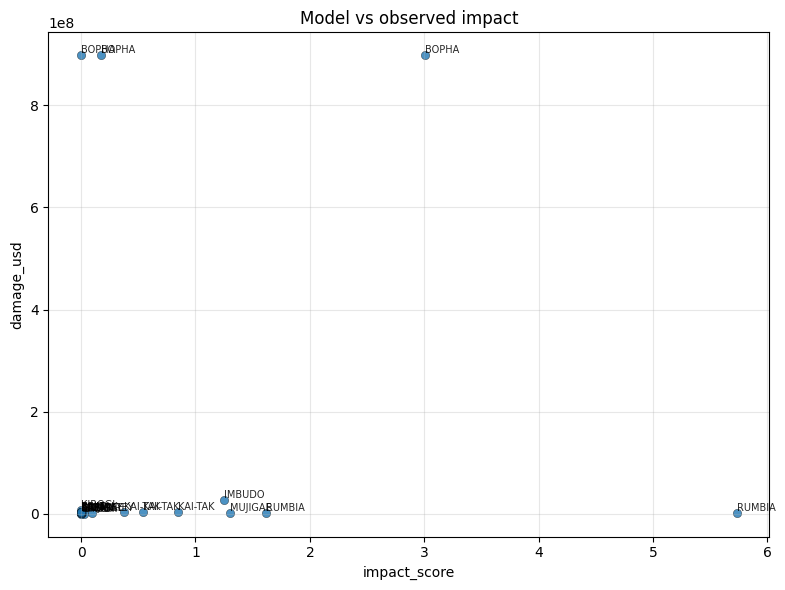

Saved merged validation table to: /home/krawalker/coding/KRITIS-PH/outputs/storm_validation_joined_debug.csv


In [ ]:
# --- External validation: correlations + scatter from master file ---

_master_candidates = [
    OUTPUT_DIR / "storm_validation_master.csv",
    REPO_ROOT / "storm_validation_master.csv",
    REPO_ROOT / "data/storm_validation_master.csv",
    OUTPUT_DIR / "storm_validation_benchmark.csv",
]
MASTER_PATH = next((p for p in _master_candidates if p.exists()), None)
if MASTER_PATH is None:
    raise FileNotFoundError(
        "No validation master CSV found. Expected one of: "
        + ", ".join(str(x) for x in _master_candidates)
    )

val = pd.read_csv(MASTER_PATH).copy()
val["storm_id"] = val["storm_id"].astype(str)

print("Loaded:", MASTER_PATH)
print("val rows:", len(val))
print("val columns:", list(val.columns))
display(val.head())

# only keep columns we actually want from master
wanted_val_cols = [
    "storm_id",
    "deaths",
    "affected_people",
    "damage_usd",
    "grid_outage_proxy",
    "restoration_proxy",
    "notes",
    "source",
]
for c in wanted_val_cols:
    if c not in val.columns:
        val[c] = np.nan
val = val[wanted_val_cols].drop_duplicates(subset=["storm_id"], keep="last")

# only bring in baseline fields that are NOT already in storm_rank_v2
_sum = ph_storm_summary[
    ["storm_id", "max_wind_kph_in_box", "n_points_in_box", "mean_wind_kph_in_box"]
].copy()
_sum["storm_id"] = _sum["storm_id"].astype(str)

# avoid duplicate-column collisions
for c in ["max_wind_kph_in_box", "n_points_in_box", "mean_wind_kph_in_box"]:
    if c in storm_rank_v2.columns:
        _sum = _sum.drop(columns=[c])

bench = storm_rank_v2.copy()
bench["storm_id"] = bench["storm_id"].astype(str)

bench = bench.merge(val, on="storm_id", how="left")
bench = bench.merge(_sum, on="storm_id", how="left")

# numeric coercion
for col in [
    "deaths",
    "affected_people",
    "damage_usd",
    "grid_outage_proxy",
    "restoration_proxy",
    "max_wind_kph_in_box",
    "n_points_in_box",
    "mean_wind_kph_in_box",
    "impact_score",
]:
    if col in bench.columns:
        bench[col] = pd.to_numeric(bench[col], errors="coerce")

print("bench rows:", len(bench))
print("Non-null counts:")
for col in [
    "impact_score",
    "damage_usd",
    "deaths",
    "affected_people",
    "grid_outage_proxy",
    "restoration_proxy",
]:
    if col in bench.columns:
        print(f"  {col}: {bench[col].notna().sum()}")

display(bench.head())

print()
print("Spearman vs impact_score:")
for col in ["deaths", "affected_people", "damage_usd", "grid_outage_proxy", "restoration_proxy"]:
    if col not in bench.columns:
        print(f"{col}: missing")
        continue
    sub = bench.dropna(subset=[col, "impact_score"])
    if len(sub) > 2:
        rho, p = spearmanr(sub["impact_score"], sub[col])
        print(f"{col}: Spearman = {rho:.3f} (p={p:.3g}, n={len(sub)})")
    else:
        print(f"{col}: need >2 paired rows, got {len(sub)}")

print()
print("Naive baselines vs damage_usd:")
for baseline in ["max_wind_kph_in_box", "n_points_in_box", "mean_wind_kph_in_box"]:
    if baseline not in bench.columns:
        print(f"{baseline}: missing")
        continue
    sub = bench.dropna(subset=[baseline, "damage_usd"])
    if len(sub) > 2:
        rho, p = spearmanr(sub[baseline], sub["damage_usd"])
        print(f"{baseline}: Spearman = {rho:.3f} (p={p:.3g}, n={len(sub)})")
    else:
        print(f"{baseline}: need >2 paired rows, got {len(sub)}")

valid = bench.dropna(subset=["impact_score", "damage_usd"]).copy()
print()
print("Points to plot (impact_score vs damage_usd):", len(valid))

fig, ax = plt.subplots(figsize=(8, 6))

if len(valid) > 0:
    ax.scatter(
        valid["impact_score"],
        valid["damage_usd"],
        alpha=0.8,
        edgecolors="k",
        linewidths=0.3,
    )

    for _, r in valid.iterrows():
        label = r["storm_name"] if pd.notna(r.get("storm_name")) else r["storm_id"]
        ax.text(
            r["impact_score"],
            r["damage_usd"],
            str(label),
            fontsize=7,
            alpha=0.85,
            ha="left",
            va="bottom",
        )
else:
    ax.text(
        0.5, 0.5,
        "No valid paired points for impact_score vs damage_usd",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

ax.set_xlabel("impact_score")
ax.set_ylabel("damage_usd")
ax.set_title("Model vs observed impact")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

out_validation = OUTPUT_DIR / "storm_validation_joined_debug.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
bench.to_csv(out_validation, index=False)
print("Saved merged validation table to:", out_validation.resolve())

In [ ]:
# --- Results digest (main path, before limitations) ---
import sys
from pathlib import Path

_n = len(storm_rank_v2)
_rank_csv = OUTPUT_DIR / "storm_rank_v2.csv"
print("Results digest")
print("  Python:", sys.version.split()[0])
print("  Storms ranked:", _n)
print("  Ranking CSV:", _rank_csv.resolve())
print("  Top storm:", storm_rank_v2.sort_values("rank").iloc[0]["storm_id"], "|", storm_rank_v2.sort_values("rank").iloc[0].get("storm_name", ""))
if "KNOWN_MAJOR_STORM_IDS" in dir() and "precision_at_k" in dir():
    _r = storm_rank_v2.sort_values("rank")["storm_id"].astype(str).tolist()
    print("  Precision@5 (known majors):", f"{precision_at_k(_r, KNOWN_MAJOR_STORM_IDS, 5):.3f}")


Results digest
  Python: 3.12.3
  Storms ranked: 323
  Ranking CSV: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_v2.csv
  Top storm: WP182006 | XANGSANE
  Precision@5 (known majors): 0.200


## Limitations

1. **Hazard simplification** — Track-point wind and radial decay only; no full wind field, terrain, rain, surge.
2. **Asset simplification** — Buses as proxy nodes; no lines, redundancy, or power flow.
3. **Weighting** — Voltage and local population are pragmatic proxies, not engineered criticality.
4. **Not loss modeling** — `impact_score` is not outage probability, damage, or economic loss.
5. **Geographic screen** — Bounding box, not exact landfall or warning polygons.

## Appendix — parameter robustness and slides

Optional material: sensitivity of the ranking to search radius and decay; deck animation for one storm.


**Methods — robustness grid.** Re-rank under a grid of `SEARCH_RADIUS_KM` × `DECAY_KM`; overlap, Spearman, and mean-rank summaries.

### Robustness (parameter grid)

Grid over **search radius** × **decay**; overlap matrices and **Spearman** between settings. Validation (known storms, placebo) is **Module 4** below.

In [ ]:
top_n = 15
top_ids = storm_rank_v2.head(top_n)["storm_id"].tolist()

decomp = (
    bus_event_df[bus_event_df["storm_id"].isin(top_ids)]
    .groupby("storm_id", as_index=False)
    .agg(
        impacted_buses=("hazard_max", lambda x: int((x > 0).sum())),
        mean_hazard_impacted=(
            "hazard_max",
            lambda x: float(np.mean(x[x > 0])) if np.any(x > 0) else 0.0,
        ),
        max_hazard=("hazard_max", "max"),
        mean_bus_weight=("bus_weight", "mean"),
        sum_bus_impact=("impact_bus", "sum"),
    )
)
decomp["storm_name"] = decomp["storm_id"].map(name_map).fillna("UNNAMED")
decomp = decomp.merge(
    storm_rank_v2[["storm_id", "rank", "year"]], on="storm_id", how="left"
).sort_values("rank")
display(decomp)

,storm_id,impacted_buses,mean_hazard_impacted,max_hazard,mean_bus_weight,sum_bus_impact,storm_name,rank,year
5,WP182006,82,0.130147,0.483497,1.490047,18.795306,XANGSANE,1,2006
2,WP072008,117,0.075873,0.299742,1.490047,16.209838,FENGSHEN,2,2008
13,WP312000,74,0.099131,0.335155,1.490047,14.236041,BEBINCA,3,2000
12,WP302000,86,0.090793,0.325112,1.490047,14.213883,XANGSANE,4,2000
11,WP262022,87,0.084132,0.187708,1.490047,13.327787,NALGAE,5,2022
8,WP222020,67,0.100074,0.624989,1.490047,12.112665,GONI,6,2020
3,WP092014,70,0.087007,0.412036,1.490047,10.928688,RAMMASUN,7,2014
7,WP182022,76,0.073054,0.511801,1.490047,9.853338,NORU,8,2022
4,WP132002,106,0.047448,0.152019,1.490047,9.491433,UNNAMED,9,2002
6,WP182021,85,0.055448,0.209223,1.490047,8.078017,CONSON,10,2021


Score drivers: a storm can rank highly from strong hazard at few buses, moderate hazard at many buses, or overlap with high-weight buses.

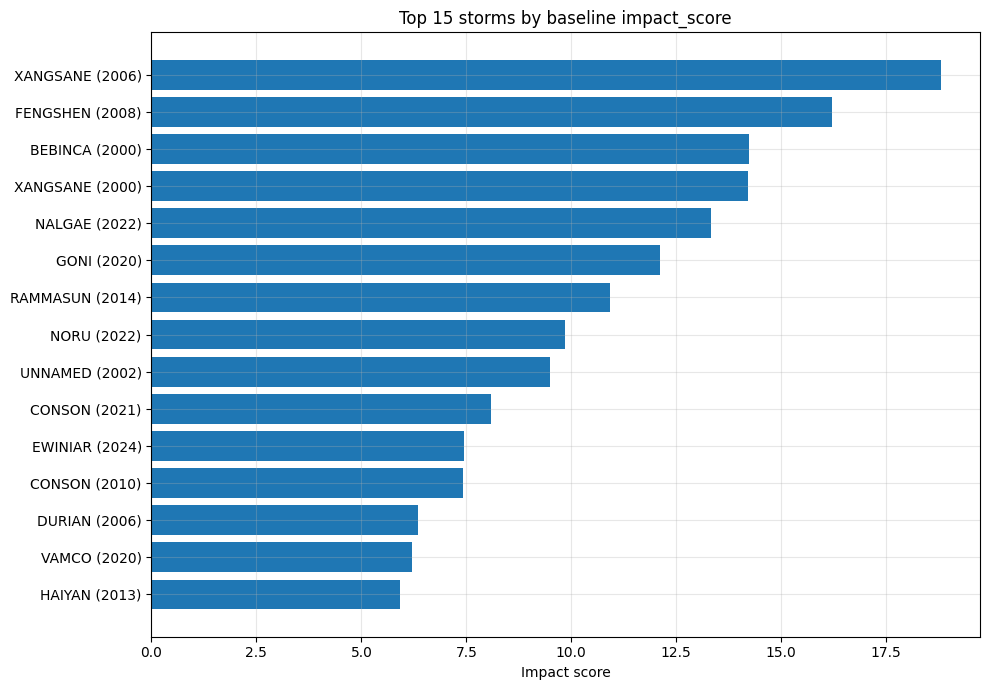

In [ ]:
plot_df = storm_rank_v2.head(15).sort_values("impact_score")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")",
    plot_df["impact_score"],
)
ax.set_title("Top 15 storms by baseline impact_score")
ax.set_xlabel("Impact score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

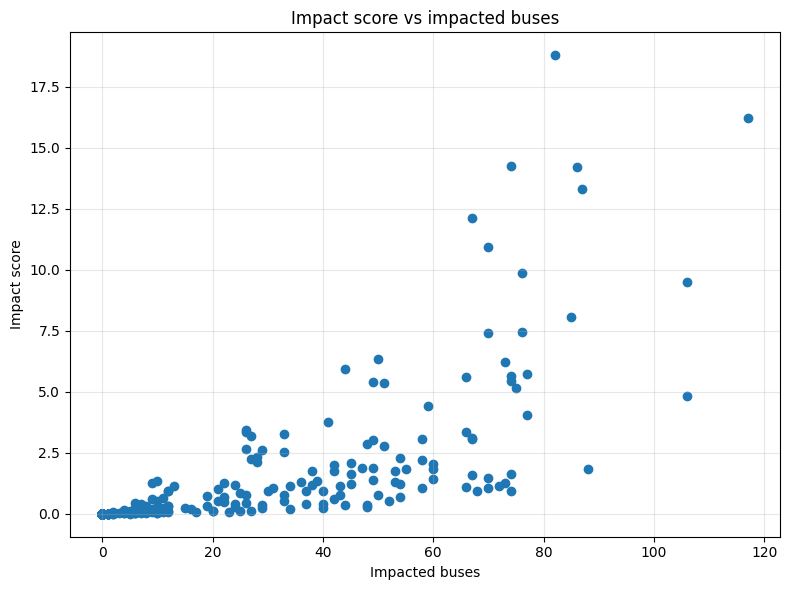

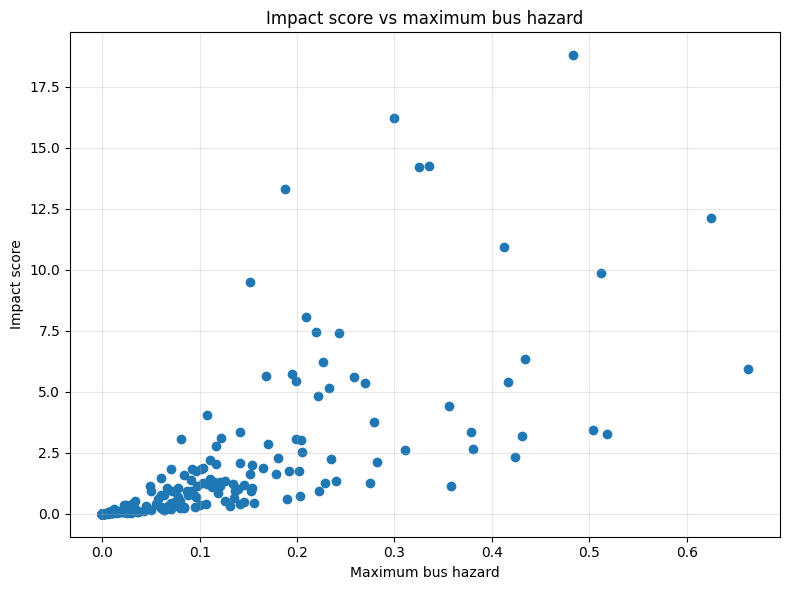

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(storm_rank_v2["impacted_buses"], storm_rank_v2["impact_score"])
ax.set_title("Impact score vs impacted buses")
ax.set_xlabel("Impacted buses")
ax.set_ylabel("Impact score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(storm_rank_v2["max_hazard"], storm_rank_v2["impact_score"])
ax.set_title("Impact score vs maximum bus hazard")
ax.set_xlabel("Maximum bus hazard")
ax.set_ylabel("Impact score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Parameter grid

In [ ]:
search_radius_values = [100.0, 150.0, 200.0]
decay_values = [20.0, 30.0, 50.0, 75.0]
param_grid = list(product(search_radius_values, decay_values))
print(f"Parameter combinations: {len(param_grid)}")

Parameter combinations: 12


In [ ]:
all_rankings = []
for search_radius_km, decay_km in param_grid:
    rank_df, _ = compute_event_rankings(
        ph_points_df=ph_points_v2,
        buses_df=buses_v2,
        search_radius_km=search_radius_km,
        decay_km=decay_km,
        name_map=name_map,
    )
    rank_df = rank_df.copy()
    rank_df["search_radius_km"] = search_radius_km
    rank_df["decay_km"] = decay_km
    all_rankings.append(rank_df)

robustness_df = pd.concat(all_rankings, ignore_index=True)
display(
    robustness_df[
        [
            "search_radius_km",
            "decay_km",
            "rank",
            "storm_name",
            "year",
            "impact_score",
        ]
    ].head(20)
)

,search_radius_km,decay_km,rank,storm_name,year,impact_score
0,100.0,20.0,1,XANGSANE,2006,10.225346
1,100.0,20.0,2,FENGSHEN,2008,8.731862
2,100.0,20.0,3,XANGSANE,2000,8.726733
3,100.0,20.0,4,GONI,2020,8.201692
4,100.0,20.0,5,BEBINCA,2000,8.012448
5,100.0,20.0,6,NALGAE,2022,7.973090
6,100.0,20.0,7,UNNAMED,2002,6.307508
7,100.0,20.0,8,RAMMASUN,2014,5.494119
8,100.0,20.0,9,NORU,2022,4.785550
9,100.0,20.0,10,EWINIAR,2024,4.482687


### Top-10 overlap across settings

In [ ]:
setting_labels = []
top10_sets = {}

for (search_radius_km, decay_km), grp in robustness_df.groupby(["search_radius_km", "decay_km"]):
    label = f"R{int(search_radius_km)}_D{int(decay_km)}"
    setting_labels.append(label)
    top10_sets[label] = set(grp.nsmallest(10, "rank")["storm_id"])

overlap_rows = []
for a in setting_labels:
    for b in setting_labels:
        inter = len(top10_sets[a].intersection(top10_sets[b]))
        overlap_rows.append({"setting_a": a, "setting_b": b, "top10_overlap": inter})

overlap_df = pd.DataFrame(overlap_rows)
overlap_pivot = overlap_df.pivot(index="setting_a", columns="setting_b", values="top10_overlap")
display(overlap_pivot)

setting_b,R100_D20,R100_D30,R100_D50,R100_D75,R150_D20,R150_D30,R150_D50,R150_D75,R200_D20,R200_D30,R200_D50,R200_D75
setting_a,,,,,,,,,,,,
R100_D20,10,9,9,8,10,9,8,8,10,9,8,8
R100_D30,9,10,10,9,9,10,9,9,9,10,9,9
R100_D50,9,10,10,9,9,10,9,9,9,10,9,9
R100_D75,8,9,9,10,8,9,10,10,8,9,10,10
R150_D20,10,9,9,8,10,9,8,8,10,9,8,8
R150_D30,9,10,10,9,9,10,9,9,9,10,9,9
R150_D50,8,9,9,10,8,9,10,10,8,9,10,10
R150_D75,8,9,9,10,8,9,10,10,8,9,10,10
R200_D20,10,9,9,8,10,9,8,8,10,9,8,8


### Spearman rank correlation across settings

In [ ]:
grouped_rankings = {
    f"R{int(sr)}_D{int(dk)}": grp[["storm_id", "rank"]].rename(
        columns={"rank": f"rank_R{int(sr)}_D{int(dk)}"}
    )
    for (sr, dk), grp in robustness_df.groupby(["search_radius_km", "decay_km"])
}

labels = list(grouped_rankings.keys())
spearman_rows = []
for i, a in enumerate(labels):
    for b in labels[i:]:
        merged = grouped_rankings[a].merge(grouped_rankings[b], on="storm_id", how="inner")
        col_a = merged.columns[1]
        col_b = merged.columns[2]
        rho, _ = spearmanr(merged[col_a], merged[col_b])
        spearman_rows.append({"setting_a": a, "setting_b": b, "spearman_rho": rho})
        if a != b:
            spearman_rows.append({"setting_a": b, "setting_b": a, "spearman_rho": rho})

spearman_df = pd.DataFrame(spearman_rows)
spearman_pivot = spearman_df.pivot(index="setting_a", columns="setting_b", values="spearman_rho")
display(spearman_pivot)

setting_b,R100_D20,R100_D30,R100_D50,R100_D75,R150_D20,R150_D30,R150_D50,R150_D75,R200_D20,R200_D30,R200_D50,R200_D75
setting_a,,,,,,,,,,,,
R100_D20,1.000000,0.996757,0.987189,0.991572,0.968682,0.964507,0.952830,0.949243,0.934480,0.929403,0.914860,0.908964
R100_D30,0.996757,1.000000,0.989745,0.994963,0.969269,0.967023,0.957577,0.954896,0.935903,0.933430,0.920350,0.915120
R100_D50,0.987189,0.989745,1.000000,0.990921,0.961439,0.962515,0.957808,0.955809,0.926933,0.927796,0.919318,0.914870
R100_D75,0.991572,0.994963,0.990921,1.000000,0.965185,0.966248,0.958288,0.956921,0.932756,0.933303,0.923215,0.919655
R150_D20,0.968682,0.969269,0.961439,0.965185,1.000000,0.993376,0.980205,0.975497,0.962249,0.957846,0.944558,0.939654
R150_D30,0.964507,0.967023,0.962515,0.966248,0.993376,1.000000,0.984694,0.980458,0.960557,0.961274,0.948698,0.945175
R150_D50,0.952830,0.957577,0.957808,0.958288,0.980205,0.984694,1.000000,0.995689,0.948299,0.952311,0.957325,0.954423
R150_D75,0.949243,0.954896,0.955809,0.956921,0.975497,0.980458,0.995689,1.000000,0.947605,0.952526,0.957532,0.956564
R200_D20,0.934480,0.935903,0.926933,0.932756,0.962249,0.960557,0.948299,0.947605,1.000000,0.995065,0.981448,0.978003


### Mean rank across the grid

In [ ]:
rank_summary = (
    robustness_df.groupby(["storm_id", "storm_name", "year"], as_index=False)
    .agg(
        mean_rank=("rank", "mean"),
        best_rank=("rank", "min"),
        worst_rank=("rank", "max"),
        appearances=("rank", "count"),
        mean_score=("impact_score", "mean"),
    )
    .sort_values(["mean_rank", "best_rank"])
    .reset_index(drop=True)
)
display(rank_summary.head(25))

,storm_id,storm_name,year,mean_rank,best_rank,worst_rank,appearances,mean_score
0,WP182006,XANGSANE,2006,1.000000,1,1,12,26.545609
1,WP072008,FENGSHEN,2008,2.000000,2,2,12,23.248259
2,WP312000,BEBINCA,2000,3.500000,3,5,12,19.595531
3,WP302000,XANGSANE,2000,4.166667,3,6,12,18.770684
4,WP262022,NALGAE,2022,5.833333,5,7,12,17.232464
5,WP092014,RAMMASUN,2014,6.250000,4,8,12,16.991802
6,WP222020,GONI,2020,6.583333,4,9,12,15.686914
7,WP182022,NORU,2022,7.416667,4,9,12,16.117587
8,WP182021,CONSON,2021,10.166667,9,12,12,12.257886
9,WP132002,UNNAMED,2002,10.500000,7,19,12,11.851053


### Post-robustness — known majors in mean-rank space

Uses **`rank_summary`** from the parameter grid (Appendix). Run the robustness section first; on **Run All**, this cell runs after the grid.


In [ ]:
ps = rank_summary.copy()
ps["known_major_flag"] = ps["storm_id"].isin(KNOWN_MAJOR_STORM_IDS)
display(ps[["storm_id", "storm_name", "year", "mean_rank", "best_rank", "mean_score", "known_major_flag"]].head(30))

terms = ["HAIYAN", "BOPHA", "RAI", "GONI", "XANGSANE", "VAMCO", "DURIAN"]
hits = []
for term in terms:
    sub = rank_summary[rank_summary["storm_name"].str.contains(term, case=False, na=False)].copy()
    sub["lookup_term"] = term
    hits.append(sub)
lookup_df = pd.concat(hits, ignore_index=True) if hits else pd.DataFrame()
if len(lookup_df):
    display(lookup_df[["lookup_term", "storm_id", "storm_name", "year", "mean_rank", "best_rank", "mean_score"]])




,storm_id,storm_name,year,mean_rank,best_rank,mean_score,known_major_flag
0,WP182006,XANGSANE,2006,1.000000,1,26.545609,True
1,WP072008,FENGSHEN,2008,2.000000,2,23.248259,False
2,WP312000,BEBINCA,2000,3.500000,3,19.595531,False
3,WP302000,XANGSANE,2000,4.166667,3,18.770684,False
4,WP262022,NALGAE,2022,5.833333,5,17.232464,False
5,WP092014,RAMMASUN,2014,6.250000,4,16.991802,False
6,WP222020,GONI,2020,6.583333,4,15.686914,False
7,WP182022,NORU,2022,7.416667,4,16.117587,False
8,WP182021,CONSON,2021,10.166667,9,12.257886,False
9,WP132002,UNNAMED,2002,10.500000,7,11.851053,False


,lookup_term,storm_id,storm_name,year,mean_rank,best_rank,mean_score
0,HAIYAN,WP312013,HAIYAN,2013,16.250000,14,9.337577
1,BOPHA,WP262012,BOPHA,2012,32.833333,27,5.574723
2,BOPHA,WP242000,BOPHA,2000,133.166667,128,0.341298
3,BOPHA,WP102006,BOPHA,2006,211.416667,165,0.000000
4,RAI,WP282021,RAI,2021,19.166667,17,8.848737
5,GONI,WP222020,GONI,2020,6.583333,4,15.686914
6,GONI,WP082009,GONI,2009,162.750000,160,0.077004
7,GONI,WP162015,GONI,2015,221.500000,179,0.011773
8,XANGSANE,WP182006,XANGSANE,2006,1.000000,1,26.545609
9,XANGSANE,WP302000,XANGSANE,2000,4.166667,3,18.770684


**Methods — animation.** Frame-by-frame cumulative max hazard at buses for one storm; saves `outputs/slide_anim_*.gif`.

### Slide animation — cumulative bus hazard (GIF)

**For decks:** this builds a **GIF** (~16×9 style figure, legible title) showing **cumulative max-over-time** hazard at each bus (same kernel as **`impact_score`**) as the track grows. Insert the GIF in **PowerPoint / Keynote / Google Slides** as an image (animation plays in presentation mode). For **MP4**, re-encode externally (e.g. ffmpeg) or switch writer if **ffmpeg** is installed.

Pick **`ANIM_STORM_RANK`** (0 = top-ranked storm). Re-run after **`storm_rank_v2`** exists.

In [ ]:
# --- Slide-oriented animation (GIF) — cumulative screening hazard at buses ---
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ANIM_STORM_RANK = 0
MAX_FRAMES = 52
FIG_W, FIG_H = 11.0, 6.2

anim_storm_id = storm_rank_v2.sort_values("rank").iloc[ANIM_STORM_RANK]["storm_id"]
track = (
    ph_points_v2[ph_points_v2["storm_id"] == anim_storm_id]
    .sort_values("t")
    .reset_index(drop=True)
)
if len(track) < 2:
    raise ValueError("Need at least 2 track points for this storm.")

max_w = float(ph_points_v2["wind_kph"].max())
if max_w <= 0 or np.isnan(max_w):
    max_w = 1.0
bus_lat = buses_v2["lat"].to_numpy()
bus_lon = buses_v2["lon"].to_numpy()

def cum_hazard_max_upto(last_idx: int) -> np.ndarray:
    h = np.zeros(len(buses_v2), dtype=float)
    for i in range(last_idx + 1):
        sp = track.iloc[i]
        d = haversine_km(bus_lat, bus_lon, sp["lat"], sp["lon"])
        near = d <= SEARCH_RADIUS_KM
        wn = float(sp["wind_kph"] / max_w)
        hz = wn * np.exp(-d / DECAY_KM)
        hz = np.where(near, hz, 0.0)
        h = np.maximum(h, hz)
    return h

npt = len(track)
if npt <= MAX_FRAMES:
    frame_idx = np.arange(npt, dtype=int)
else:
    frame_idx = np.unique(np.linspace(0, npt - 1, MAX_FRAMES, dtype=int))

global_hmax = 0.0
for k in frame_idx:
    global_hmax = max(global_hmax, float(np.max(cum_hazard_max_upto(k))))
if global_hmax <= 0:
    global_hmax = 1.0

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=120)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [
        PH_BOUNDS["lon_min"],
        PH_BOUNDS["lon_max"],
        PH_BOUNDS["lat_min"],
        PH_BOUNDS["lat_max"],
    ],
    crs=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.LAND, alpha=0.22)
ax.add_feature(cfeature.COASTLINE, linewidth=0.65)
ax.add_feature(cfeature.BORDERS, linewidth=0.25)
gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.35)
gl.top_labels = False
gl.right_labels = False

(line,) = ax.plot(
    [],
    [],
    transform=ccrs.PlateCarree(),
    color="crimson",
    linewidth=2.2,
    alpha=0.95,
    zorder=5,
)
sc = ax.scatter(
    bus_lon,
    bus_lat,
    transform=ccrs.PlateCarree(),
    s=28,
    c=np.zeros(len(buses_v2)),
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    edgecolors="0.2",
    linewidths=0.25,
    zorder=4,
)

sn = str(name_map.get(str(anim_storm_id), "UNNAMED"))
yr = track["year"].iloc[0]
try:
    yr = int(yr)
except (TypeError, ValueError):
    yr = -1
title = ax.set_title("", fontsize=11, fontweight="bold")


def update(fi):
    k = int(frame_idx[fi])
    h = cum_hazard_max_upto(k)
    c = h / global_hmax
    sc.set_array(c)
    lon_t = track.loc[:k, "lon"].to_numpy()
    lat_t = track.loc[:k, "lat"].to_numpy()
    line.set_data(lon_t, lat_t)
    tcell = track.iloc[k]["time"]
    tstr = str(tcell)[:19] if tcell is not None else f"step {k}"
    title.set_text(f"{sn} ({yr})  [{anim_storm_id}]\nCumulative bus hazard (normalized) — {tstr}")
    return (sc, line, title)


ani = animation.FuncAnimation(
    fig, update, frames=len(frame_idx), interval=200, blit=False
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_gif = OUTPUT_DIR / f"slide_anim_{anim_storm_id}.gif"
try:
    ani.save(out_gif, writer=animation.PillowWriter(fps=5))
    print("Saved for slides:", out_gif.resolve())
    print("Frames:", len(frame_idx), "| Fig ~16:9 style for projection")
except Exception as exc:
    print("GIF export failed (try: pip install pillow):", exc)

plt.close(fig)


Saved for slides: /home/krawalker/coding/KRITIS-PH/outputs/slide_anim_WP182006.gif
Frames: 14 | Fig ~16:9 style for projection


## Main conclusions

- The event score uses **max-over-time** hazard at each bus so the same asset is not inflated by many close track timesteps.
- Rankings are a **first-order KRITIS-style screen** for grid-relevant storm exposure.
- Robustness analysis shows how sensitive the ordering is to radius and decay parameters.
- **Modules 3–4** add network-adjusted bus weights and validation (precision@k, placebo); they do not turn the metric into a loss or outage model.
- This remains a screening prototype, not an operational fragility or risk model.